# VSX–TESS Data Pipeline: What, Why, and How

This notebook documents the data pipeline used to construct a labeled variable-star light-curve dataset. The project starts with variable-star categories from **AAVSO VSX**, maps VSX sources to likely **TESS Input Catalog (TIC)** identifiers, and retrieves usable TESS light curves through a hierarchy of **SPOC → QLP → TESSCut**.

The notebook is intended to serve as both a demonstration and a methodology document.

## 1. Why choose AAVSO VSX as the label source?

AAVSO VSX is used because it provides a large public catalog of known variable stars with sky coordinates and variability classifications. For this research project, VSX supplies the supervised-learning labels: the variable-star class or family.

TESS provides high-quality photometry, but it does not by itself provide a clean labeled dataset for all variable-star classes. VSX fills that role. The tradeoff is that VSX is not already linked one-to-one to TIC identifiers, so the pipeline must solve a crossmatching problem before light curves can be downloaded.

## 2. Why choose TESS light curves as the data source?

TESS is chosen because it provides large-scale, space-based time-domain photometry across much of the sky. Variable stars are naturally studied through light curves, and TESS data are well suited for period analysis, feature extraction, and machine-learning classification.

TESS data can be accessed through several product types:

- **SPOC**: high-quality pipeline light curves, but limited coverage.
- **QLP**: broader availability, useful when SPOC is missing.
- **TESSCut**: fallback access to full-frame image cutouts, enabling custom light-curve extraction.

The key lesson from this project is that SPOC/QLP alone miss most usable VSX targets; TESSCut is essential for high coverage.

## 3. Imports and representative examples

We use three stars to demonstrate the logic:

| VSX ID | RA (deg) | Dec (deg) | Final recovery path |
|---|---:|---:|---|
| LMC V0827 | 76.02176 | -66.29695 | TESSCut |
| OGLE-GD-CEP-0948 | 206.05846 | -63.67383 | SPOC |
| ZTF J212148.91+495425.9 | 320.45383 | 49.90721 | QLP |

In [1]:
import warnings
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.io import fits

try:
    from astroquery.mast import Catalogs
    ASTROQUERY_AVAILABLE = True
except Exception as e:
    ASTROQUERY_AVAILABLE = False
    print("astroquery is not available:", e)

try:
    import lightkurve as lk
    LIGHTKURVE_AVAILABLE = True
except Exception as e:
    LIGHTKURVE_AVAILABLE = False
    print("lightkurve is not available:", e)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 140)

In [2]:
vsx_examples = pd.DataFrame([
    {"vsx_id": "LMC V0827", "ra_deg": 76.02176, "dec_deg": -66.29695, "expected_final_method": "TESSCut"},
    {"vsx_id": "OGLE-GD-CEP-0948", "ra_deg": 206.05846, "dec_deg": -63.67383, "expected_final_method": "SPOC"},
    {"vsx_id": "ZTF J212148.91+495425.9", "ra_deg": 320.45383, "dec_deg": 49.90721, "expected_final_method": "QLP"},
])
vsx_examples

,vsx_id,ra_deg,dec_deg,expected_final_method
0,LMC V0827,76.02176,-66.29695,TESSCut
1,OGLE-GD-CEP-0948,206.05846,-63.67383,SPOC
2,ZTF J212148.91+495425.9,320.45383,49.90721,QLP


## 4. Original idea: nearest TIC by RA/Dec

The original idea was:

1. take the VSX RA/Dec,
2. query nearby TIC sources,
3. compute angular separation,
4. pick the nearest TIC source,
5. search for a SPOC light curve.

This is a reasonable baseline, but it is incomplete. A correct TIC counterpart may lack a SPOC product, and in crowded fields a single nearest match can be fragile.

In [3]:
def query_tic_candidates(ra_deg, dec_deg, radius_arcsec=10.0, max_candidates=5):
    if not ASTROQUERY_AVAILABLE:
        raise RuntimeError("astroquery is not available in this environment.")

    vsx_coord = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame="icrs")
    tic_table = Catalogs.query_region(vsx_coord, radius=radius_arcsec * u.arcsec, catalog="TIC")

    rows = []
    for row in tic_table:
        if "ra" not in row.colnames or "dec" not in row.colnames or "ID" not in row.colnames:
            continue

        tic_ra = float(row["ra"])
        tic_dec = float(row["dec"])
        tic_coord = SkyCoord(ra=tic_ra * u.deg, dec=tic_dec * u.deg, frame="icrs")
        sep_arcsec = vsx_coord.separation(tic_coord).arcsec

        tmag = np.nan
        if "Tmag" in row.colnames:
            try:
                tmag = float(row["Tmag"])
            except Exception:
                pass

        rows.append({
            "tic_id": str(row["ID"]),
            "tic_ra_deg": tic_ra,
            "tic_dec_deg": tic_dec,
            "tic_tmag": tmag,
            "sep_arcsec": float(sep_arcsec),
        })

    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df
    return df.sort_values("sep_arcsec").head(max_candidates).reset_index(drop=True)

In [4]:
candidate_tables = {}
for _, star in vsx_examples.iterrows():
    try:
        cand = query_tic_candidates(star["ra_deg"], star["dec_deg"], radius_arcsec=10.0, max_candidates=5)
        candidate_tables[star["vsx_id"]] = cand
        print("\n" + "=" * 80)
        print(star["vsx_id"])
        display(cand)
    except Exception as e:
        print(f"Could not query TIC candidates for {star['vsx_id']}: {e}")


LMC V0827


,tic_id,tic_ra_deg,tic_dec_deg,tic_tmag,sep_arcsec
0,30855441,76.021760,-66.296952,15.4546,0.008897
1,683451050,76.023475,-66.297907,18.9523,4.244537
2,683724349,76.019141,-66.296200,18.8881,4.653703
3,683724347,76.017614,-66.295641,19.6595,7.628325
4,683724346,76.016984,-66.298160,19.8566,8.170504



OGLE-GD-CEP-0948


,tic_id,tic_ra_deg,tic_dec_deg,tic_tmag,sep_arcsec
0,321957546,206.058487,-63.673819,14.8222,0.058597
1,1024599055,206.055758,-63.674656,19.0471,5.238685
2,1024599054,206.060755,-63.675032,19.4638,5.670392
3,321957525,206.060192,-63.675390,14.0628,6.259872
4,1024599065,206.061542,-63.671929,20.1264,8.430062



ZTF J212148.91+495425.9


,tic_id,tic_ra_deg,tic_dec_deg,tic_tmag,sep_arcsec
0,63711350,320.453837,49.907200,13.2980,0.039886
1,2016781083,320.454805,49.907377,18.4814,2.338931
2,2016782508,320.453037,49.907888,14.9541,3.057514
3,2016781082,320.455256,49.907281,17.1558,3.317077
4,2016782501,320.452621,49.906119,19.3314,4.826132


## 5. SPOC-only search: first bottleneck

Using the nearest TIC and searching only SPOC recovers only the SPOC example. This demonstrates that **missing SPOC does not mean missing TESS data**.

In [5]:
known_examples = pd.DataFrame([
    {"vsx_id": "LMC V0827", "tic_id": "30855441", "expected_final_method": "TESSCut"},
    {"vsx_id": "OGLE-GD-CEP-0948", "tic_id": "321957546", "expected_final_method": "SPOC"},
    {"vsx_id": "ZTF J212148.91+495425.9", "tic_id": "63711350", "expected_final_method": "QLP"},
])

def count_lightcurve_products(tic_id, author):
    if not LIGHTKURVE_AVAILABLE:
        return np.nan
    try:
        return len(lk.search_lightcurve(f"TIC {tic_id}", mission="TESS", author=author))
    except Exception as e:
        print(f"Warning: search_lightcurve failed for TIC {tic_id}, author={author}: {e}")
        return np.nan

def count_tesscut_products(tic_id):
    if not LIGHTKURVE_AVAILABLE:
        return np.nan
    try:
        return len(lk.search_tesscut(f"TIC {tic_id}"))
    except Exception as e:
        print(f"Warning: search_tesscut failed for TIC {tic_id}: {e}")
        return np.nan

spoc_demo = known_examples.copy()
spoc_demo["SPOC_count"] = spoc_demo["tic_id"].apply(lambda x: count_lightcurve_products(x, "SPOC"))
spoc_demo["SPOC_found"] = spoc_demo["SPOC_count"] > 0
spoc_demo

No data found for target "TIC 30855441".
No data found for target "TIC 63711350".


,vsx_id,tic_id,expected_final_method,SPOC_count,SPOC_found
0,LMC V0827,30855441,TESSCut,0,False
1,OGLE-GD-CEP-0948,321957546,SPOC,1,True
2,ZTF J212148.91+495425.9,63711350,QLP,0,False


## 6. Improvement: top-5 candidates and SPOC → QLP

The improved pipeline stores up to five TIC candidates per VSX star. It then searches each candidate in distance order, first for SPOC and then for QLP.

This recovers cases like **ZTF J212148.91+495425.9**, which lacks SPOC but has QLP.

In [6]:
spoc_qlp_demo = known_examples.copy()
spoc_qlp_demo["SPOC_count"] = spoc_qlp_demo["tic_id"].apply(lambda x: count_lightcurve_products(x, "SPOC"))
spoc_qlp_demo["QLP_count"] = spoc_qlp_demo["tic_id"].apply(lambda x: count_lightcurve_products(x, "QLP"))

def select_spoc_or_qlp(row):
    if row["SPOC_count"] > 0:
        return "SPOC"
    if row["QLP_count"] > 0:
        return "QLP"
    return None

spoc_qlp_demo["Selected_after_SPOC_QLP"] = spoc_qlp_demo.apply(select_spoc_or_qlp, axis=1)
spoc_qlp_demo

No data found for target "TIC 30855441".
No data found for target "TIC 321957546".


,vsx_id,tic_id,expected_final_method,SPOC_count,QLP_count,Selected_after_SPOC_QLP
0,LMC V0827,30855441,TESSCut,0,0,NaN
1,OGLE-GD-CEP-0948,321957546,SPOC,1,0,SPOC
2,ZTF J212148.91+495425.9,63711350,QLP,0,4,QLP


## 7. Final fallback: TESSCut

If no candidate has SPOC or QLP, the pipeline uses TESSCut at the nearest TIC candidate coordinate. TESSCut provides full-frame image cutouts from which the pipeline extracts a 1D light curve.

This recovers cases like **LMC V0827**.

In [7]:
final_demo = spoc_qlp_demo.copy()
final_demo["TESSCut_count"] = final_demo["tic_id"].apply(count_tesscut_products)

def select_final_method(row):
    if row["SPOC_count"] > 0:
        return "SPOC"
    if row["QLP_count"] > 0:
        return "QLP"
    if row["TESSCut_count"] > 0:
        return "TESSCut"
    return "Missing"

final_demo["Final_selected_method"] = final_demo.apply(select_final_method, axis=1)
final_demo

,vsx_id,tic_id,expected_final_method,SPOC_count,QLP_count,Selected_after_SPOC_QLP,TESSCut_count,Final_selected_method
0,LMC V0827,30855441,TESSCut,0,0,NaN,45,TESSCut
1,OGLE-GD-CEP-0948,321957546,SPOC,1,0,SPOC,6,SPOC
2,ZTF J212148.91+495425.9,63711350,QLP,0,4,QLP,4,QLP


## 8. Final pipeline logic

```text
For each VSX star:
    query TIC candidates near VSX RA/Dec
    keep up to 5 candidates sorted by angular distance

Metadata phase:
    batch query unique TIC candidates for SPOC/QLP availability
    select first candidate with SPOC, otherwise first with QLP
    if none, mark bestMatch = None

Download phase:
    if bestMatch exists: download SPOC/QLP
    otherwise: use nearest TIC candidate for TESSCut extraction

Storage:
    save raw FITS
    save standardized FITS
    save metadata and QC status
```

## 9. Raw and standardized light curves

A key issue solved during development was avoiding blind standardization. Standardizing flux too early can erase information needed for physical interpretation, such as amplitude or original flux scale.

The final pipeline saves:

1. **raw light curve**: native flux values,
2. **standardized light curve**: cleaned and normalized version for ML.

Standardization is skipped or flagged when the light curve is all-NaN, has too few valid points, or has near-zero variance.

## 10. FITS sanity-check logic

The pipeline includes a FITS validation script based on the following checks:

- can the file be opened?
- is there a recognizable TIME/FLUX table?
- does it look like a final 1D light curve rather than an image cube?
- how many finite time/flux rows are present?
- is the finite fraction acceptable?
- is the time span positive?
- is the flux scatter nonzero?
- is the file suspiciously small?

This protects the downstream feature-extraction and ML stages.

In [8]:
TIME_COL_CANDIDATES = ["TIME", "BJD", "TIMECORR"]
FLUX_COL_CANDIDATES = ["FLUX", "SAP_FLUX", "PDCSAP_FLUX", "KSPSAP_FLUX", "RAW_FLUX"]

@dataclass
class FitsScanResult:
    path: str
    size_bytes: int
    verdict: str
    suspicious: bool
    has_time_flux_table: bool
    has_image_hdu: bool
    hdu_count: int
    table_hdu_index: Optional[int]
    time_col: Optional[str]
    flux_col: Optional[str]
    total_rows: Optional[int]
    finite_rows: Optional[int]
    finite_fraction: Optional[float]
    time_span: Optional[float]
    flux_std: Optional[float]
    issues: str

def find_time_flux_pair(hdul):
    for i, hdu in enumerate(hdul):
        data = hdu.data
        names = getattr(data, "names", None)
        if names is None:
            continue
        names_upper = {n.upper(): n for n in names}
        time_col = next((names_upper[t] for t in TIME_COL_CANDIDATES if t in names_upper), None)
        flux_col = next((names_upper[f] for f in FLUX_COL_CANDIDATES if f in names_upper), None)
        if time_col and flux_col:
            return i, time_col, flux_col
    return None, None, None

def classify_fits_file(path, min_size_kb=50, min_finite_rows=100, min_finite_fraction=0.50):
    path = Path(path)
    issues = []
    size_bytes = path.stat().st_size

    if size_bytes < min_size_kb * 1024:
        issues.append(f"small_file<{min_size_kb}KB")

    try:
        with fits.open(path) as hdul:
            hdu_count = len(hdul)
            has_image = any(isinstance(h.data, np.ndarray) and h.data.ndim >= 2 and h.data.size > 0 for h in hdul)
            hdu_idx, time_col, flux_col = find_time_flux_pair(hdul)
            has_time_flux = hdu_idx is not None

            total_rows = finite_rows = finite_fraction = time_span = flux_std = None

            if has_time_flux:
                table = hdul[hdu_idx].data
                total_rows = len(table)
                time = np.asarray(table[time_col], dtype=float)
                flux = np.asarray(table[flux_col], dtype=float)
                finite = np.isfinite(time) & np.isfinite(flux)
                finite_rows = int(finite.sum())
                finite_fraction = finite_rows / total_rows if total_rows else None
                if finite_rows > 0:
                    time_span = float(np.nanmax(time[finite]) - np.nanmin(time[finite]))
                    flux_std = float(np.nanstd(flux[finite]))

            if has_time_flux:
                verdict = "LIKELY_FINAL_LIGHT_CURVE_FITS"
            elif has_image:
                verdict = "LIKELY_IMAGE_OR_TESSCUT_PRODUCT"
            else:
                verdict = "UNCLEAR_OR_METADATA_ONLY"

            if not has_time_flux:
                issues.append("no_recognizable_time_flux_table")
            if total_rows == 0:
                issues.append("empty_time_flux_table")
            if finite_rows is not None and finite_rows < min_finite_rows:
                issues.append(f"too_few_finite_rows<{min_finite_rows}")
            if finite_fraction is not None and finite_fraction < min_finite_fraction:
                issues.append(f"low_finite_fraction<{min_finite_fraction:.2f}")
            if time_span is not None and time_span <= 0:
                issues.append("non_positive_time_span")
            if flux_std is not None and flux_std == 0:
                issues.append("zero_flux_scatter")

            return FitsScanResult(
                path=str(path), size_bytes=size_bytes, verdict=verdict,
                suspicious=len(issues) > 0, has_time_flux_table=has_time_flux,
                has_image_hdu=has_image, hdu_count=hdu_count, table_hdu_index=hdu_idx,
                time_col=time_col, flux_col=flux_col, total_rows=total_rows,
                finite_rows=finite_rows, finite_fraction=finite_fraction,
                time_span=time_span, flux_std=flux_std, issues=";".join(issues)
            )

    except Exception as e:
        return FitsScanResult(
            path=str(path), size_bytes=size_bytes, verdict="FAILED_TO_OPEN",
            suspicious=True, has_time_flux_table=False, has_image_hdu=False,
            hdu_count=0, table_hdu_index=None, time_col=None, flux_col=None,
            total_rows=None, finite_rows=None, finite_fraction=None,
            time_span=None, flux_std=None, issues=f"open_error:{type(e).__name__}:{e}"
        )

In [9]:
def determine_qc_status(scan_result):
    status = "pass"
    issues = []

    if scan_result.verdict == "FAILED_TO_OPEN":
        status = "fail"
        issues.append("failed_to_open")

    if scan_result.verdict == "UNCLEAR_OR_METADATA_ONLY" and not scan_result.has_time_flux_table:
        status = "fail"
        issues.append("no_time_flux_table")

    if scan_result.finite_rows is not None and scan_result.finite_rows < 100:
        status = "fail"
        issues.append("too_few_finite_rows")

    if scan_result.finite_fraction is not None and scan_result.finite_fraction < 0.50:
        status = "fail"
        issues.append("low_finite_fraction")

    if status != "fail":
        warning_flags = []
        if scan_result.finite_fraction is not None and 0.50 <= scan_result.finite_fraction < 0.75:
            warning_flags.append("marginal_finite_fraction")
        if scan_result.finite_rows is not None and 100 <= scan_result.finite_rows < 300:
            warning_flags.append("marginal_row_count")
        if scan_result.size_bytes < 50 * 1024:
            warning_flags.append("small_file")
        if warning_flags:
            status = "warning"
            issues.extend(warning_flags)

    return status, ";".join(issues) if issues else "all_checks_passed"

## 11. Practical issues solved during pipeline development

The following issues were identified and addressed:

- **Non-unique VSX → TIC matching:** solved by keeping up to five TIC candidates.
- **Very low SPOC-only coverage:** initial coverage was approximately 12%, with RR Lyrae initially around 1.4%.
- **Efficient availability lookup:** solved by batch-querying TIC candidates for SPOC/QLP availability.
- **TESSCut fallback:** added to recover stars missing from SPOC/QLP.
- **Candidate-centered TESSCut:** fallback uses nearest TIC candidate coordinates.
- **Raw vs standardized preservation:** both versions are saved.
- **FITS sanity checking:** added to detect bad files before feature extraction.
- **Conservative parallelism:** large download was run with limited concurrency for stability.
- **Long-trend handling:** deferred to a later preprocessing module so that real astrophysical variability is not removed blindly.

## 12. Final coverage results

The final pipeline was applied to **7,370 variable-star candidates**.

| Provenance | Count | Percent |
|---|---:|---:|
| TESSCut | 5,034 | 68.30% |
| SPOC | 467 | 6.34% |
| QLP | 1,612 | 21.87% |
| Missing | 257 | 3.49% |

Final usable coverage is approximately **96.5%**.

Earlier stages:

- nearest TIC + SPOC only: approximately **12%**
- top-5 candidates + SPOC/QLP: approximately **22.5%**
- final SPOC/QLP/TESSCut pipeline: **96.5%**

In [10]:
overall_provenance = pd.DataFrame([
    {"Provenance": "TESSCut", "Count": 5034, "Percent": 68.30},
    {"Provenance": "SPOC", "Count": 467, "Percent": 6.34},
    {"Provenance": "QLP", "Count": 1612, "Percent": 21.87},
    {"Provenance": "Missing", "Count": 257, "Percent": 3.49},
])

coverage_stages = pd.DataFrame([
    {"Stage": "Nearest TIC + SPOC only\n(initial idea)", "CoveragePercent": 12.0},
    {"Stage": "Top-5 candidates +\nSPOC/QLP", "CoveragePercent": 22.5},
    {"Stage": "Top-5 candidates +\nSPOC/QLP/TESSCut", "CoveragePercent": 96.51},
])

display(overall_provenance)
display(coverage_stages)

,Provenance,Count,Percent
0,TESSCut,5034,68.30
1,SPOC,467,6.34
2,QLP,1612,21.87
3,Missing,257,3.49


,Stage,CoveragePercent
0,Nearest TIC + SPOC only\n(initial idea),12.00
1,Top-5 candidates +\nSPOC/QLP,22.50
2,Top-5 candidates +\nSPOC/QLP/TESSCut,96.51


### Figure 1. Coverage improvement across pipeline stages

**Caption:** Usable TESS light curve coverage improves from approximately 12% under the initial nearest-TIC/SPOC-only strategy to 22.5% after allowing up to five TIC candidates and searching SPOC/QLP products. Adding TESSCut fallback increases final usable coverage to 96.5%.

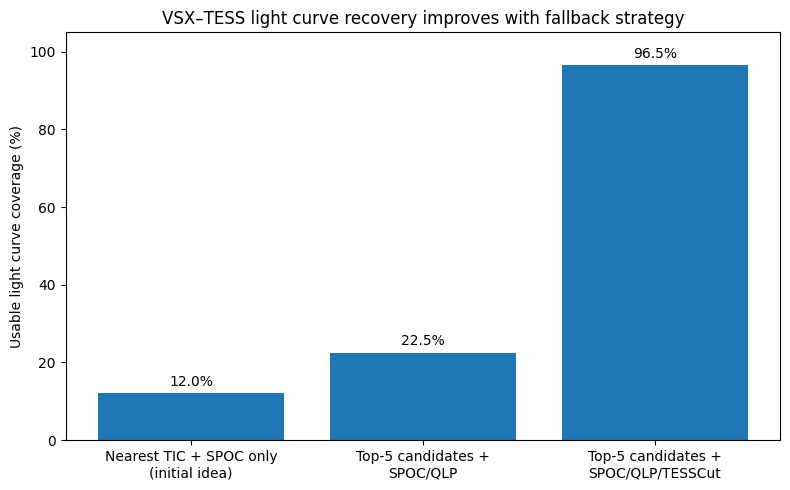

In [11]:
plt.figure(figsize=(8, 5))
bars = plt.bar(coverage_stages["Stage"], coverage_stages["CoveragePercent"])
plt.ylabel("Usable light curve coverage (%)")
plt.ylim(0, 105)
plt.title("VSX–TESS light curve recovery improves with fallback strategy")

for bar, value in zip(bars, coverage_stages["CoveragePercent"]):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 2, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.savefig("coverage_improvement_stages.png", dpi=200, bbox_inches="tight")
plt.show()

## 13. Family-level final results

In [12]:
family_stats = pd.DataFrame([
    {"Family": "CEPHEID", "TESSCut": 639, "SPOC": 29, "QLP": 168, "Missing": 0, "Total": 836},
    {"Family": "CV", "TESSCut": 525, "SPOC": 66, "QLP": 4, "Missing": 0, "Total": 595},
    {"Family": "DSCT_SXPHE", "TESSCut": 766, "SPOC": 34, "QLP": 153, "Missing": 0, "Total": 953},
    {"Family": "ECLIPSING", "TESSCut": 814, "SPOC": 8, "QLP": 174, "Missing": 0, "Total": 996},
    {"Family": "ELLIPSOIDAL_ROT", "TESSCut": 705, "SPOC": 122, "QLP": 170, "Missing": 0, "Total": 997},
    {"Family": "LONG_PERIOD", "TESSCut": 173, "SPOC": 90, "QLP": 717, "Missing": 0, "Total": 980},
    {"Family": "RRLYR", "TESSCut": 934, "SPOC": 3, "QLP": 39, "Missing": 0, "Total": 976},
    {"Family": "XRAY", "TESSCut": 20, "SPOC": 24, "QLP": 12, "Missing": 0, "Total": 56},
    {"Family": "YSO", "TESSCut": 458, "SPOC": 91, "QLP": 175, "Missing": 0, "Total": 724},
])

for col in ["TESSCut", "SPOC", "QLP", "Missing"]:
    family_stats[col + "_pct"] = 100 * family_stats[col] / family_stats["Total"]

family_stats

,Family,TESSCut,SPOC,QLP,Missing,Total,TESSCut_pct,SPOC_pct,QLP_pct,Missing_pct
0,CEPHEID,639,29,168,0,836,76.435407,3.468900,20.095694,0.0
1,CV,525,66,4,0,595,88.235294,11.092437,0.672269,0.0
2,DSCT_SXPHE,766,34,153,0,953,80.377754,3.567681,16.054565,0.0
3,ECLIPSING,814,8,174,0,996,81.726908,0.803213,17.469880,0.0
4,ELLIPSOIDAL_ROT,705,122,170,0,997,70.712136,12.236710,17.051153,0.0
5,LONG_PERIOD,173,90,717,0,980,17.653061,9.183673,73.163265,0.0
6,RRLYR,934,3,39,0,976,95.696721,0.307377,3.995902,0.0
7,XRAY,20,24,12,0,56,35.714286,42.857143,21.428571,0.0
8,YSO,458,91,175,0,724,63.259669,12.569061,24.171271,0.0


### Figure 2. Provenance composition by family

**Caption:** Final light curve provenance differs strongly by variable-star family. RR Lyrae, eclipsing, DSCT/SX Phe, and Cepheid stars rely heavily on TESSCut, while long-period variables are primarily recovered through QLP.

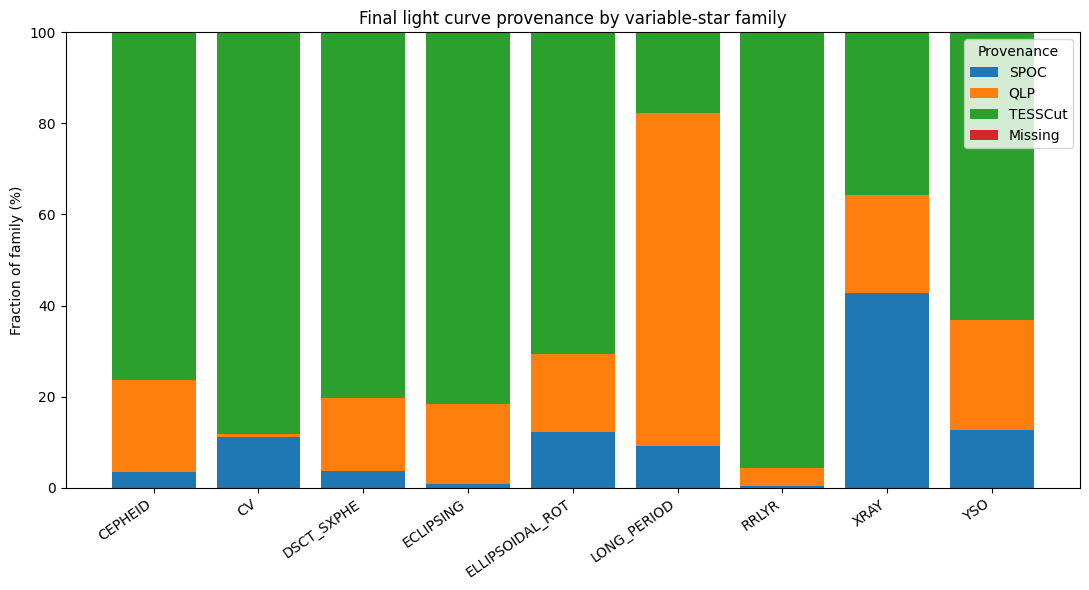

In [13]:
plot_df = family_stats.set_index("Family")[["SPOC_pct", "QLP_pct", "TESSCut_pct", "Missing_pct"]]

plt.figure(figsize=(11, 6))
bottom = np.zeros(len(plot_df))

for col in plot_df.columns:
    values = plot_df[col].values
    plt.bar(plot_df.index, values, bottom=bottom, label=col.replace("_pct", ""))
    bottom += values

plt.ylabel("Fraction of family (%)")
plt.title("Final light curve provenance by variable-star family")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Provenance")
plt.tight_layout()
plt.savefig("family_provenance_breakdown.png", dpi=200, bbox_inches="tight")
plt.show()

## 14. Main findings

1. VSX is a practical label source, but it requires careful crossmatching to TIC.
2. TESS is an excellent light-curve source, but standard products are incomplete.
3. Nearest-TIC + SPOC-only is too restrictive.
4. Top-5 candidate matching plus QLP improves coverage.
5. TESSCut is essential, contributing 5,034 light curves.
6. Final usable coverage reaches 96.5%.
7. Quality control and raw-data preservation are necessary for later feature extraction and ML.

The data pipeline is therefore a major methodological contribution, not merely a download step.

## 15. Future preprocessing: long-trend handling

Long-term trend removal was intentionally deferred. Some trends may be instrumental, but some may be astrophysical, especially for long-period variables. The planned approach is to add a separate trend-detection and detrending module after the raw and standardized datasets are safely preserved.

# 16. Cross-match Reliability Analysis: Validating the Pipeline Assumption

The sections above describe the VSX → TIC → TESS light-curve data pipeline and why each fallback step was introduced.  
This final integrated section tests the most important methodological assumption behind the pipeline:

> Are the TESSCut fallback light curves likely associated with the intended VSX/TIC counterparts, rather than being dominated by cross-match mistakes?

This matters because the Random Forest analysis showed lower performance for TESSCut-derived light curves. A natural alternative explanation is that TESSCut objects may be incorrectly matched. The following analysis evaluates that concern directly using the full augmented metadata parquet and, when available, the held-out test prediction parquet.


### 16.0. Purpose of this reliability section

This section evaluates whether the VSX → TIC mapping used by the TESS light-curve pipeline is reliable enough to support downstream astrophysical and ML conclusions.

The core question is:

> Are TESSCut fallback light curves likely centered on the correct TIC counterpart for each VSX object?

This is **not** a train/validation/test analysis. It should be run on the full augmented metadata parquet because cross-match reliability is a property of the data pipeline, not a model generalization metric.

The notebook keeps the conclusion conservative: it does **not** claim that every mapping is correct. Instead, it tests whether there is evidence for **large-scale cross-match failure** that could plausibly explain the TESSCut Random Forest performance degradation.

In [14]:
# ============================================================
# User-editable input paths
# ============================================================

# Main metadata parquet from the data pipeline.
# Recommended: latest full augmented metadata table, not train/validation/test split.
INPUT_PARQUET = "/data/projects/TESS-research/detrend_tesscut/output/TESSAugmented_QC_tesscut_conditional_detrended.parquet"

# Optional: prediction parquet from ML analysis.
# Leave as None if you only want mapping reliability analysis.
# Example: "/data/projects/TESS-research/ml_analytics/output/test_predictions.parquet"
PREDICTION_PARQUET = "/data/projects/TESS-research/ml_analytics/output/test_predictions.parquet"

# Optional output folder for plots/tables.
OUTPUT_DIR = "/data/projects/TESS-research/mapping_reliability/output"

# Distance thresholds in arcseconds for confidence buckets.
# These are analysis heuristics, not universal astrophysical truth.
HIGH_CONF_ARCSEC = 2.0
MEDIUM_CONF_ARCSEC = 5.0
LOW_CONF_ARCSEC = 10.0

# Ambiguity heuristics. These are intentionally conservative.
# A row is positionally ambiguous if multiple TIC candidates are very close to the VSX position.
AMBIGUOUS_WITHIN_ARCSEC = 5.0
CLOSE_COMPETITOR_RATIO = 2.0


In [15]:
from pathlib import Path
import ast
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("Input parquet:", INPUT_PARQUET)
print("Output folder:", OUTPUT_DIR)

try:
    from scipy.stats import mannwhitneyu, ks_2samp, chi2_contingency
    SCIPY_AVAILABLE = True
except Exception as exc:
    SCIPY_AVAILABLE = False
    print("scipy not available; statistical-test cells will use descriptive summaries only:", exc)


Input parquet: /data/projects/TESS-research/detrend_tesscut/output/TESSAugmented_QC_tesscut_conditional_detrended.parquet
Output folder: /data/projects/TESS-research/mapping_reliability/output


### 16.1. Load metadata and inspect available columns

The input file should contain the VSX metadata, TIC candidate list, selected `bestMatch`, `provenance`, and light-curve availability fields.

In [16]:
df = pd.read_parquet(INPUT_PARQUET)
print("Rows:", len(df))
print("Columns:")
print(list(df.columns))

display(df.head(3))

Rows: 7370
Columns:
['VSXId', 'VSXName', 'VSXType', 'period', 'family', 'raDeg', 'decDeg', 'rawRow', 'ticCandidates', 'bestMatch', 'provenance', 'lightCurvePath', 'rawLightCurvePath', 'extractionMetadata', 'lightCurveAvailable', 'noLightCurveReason', 'normalizationApplied', 'fluxMedian', 'fluxStd', 'fluxSnr', 'medianUnstable', 'lowSNR', 'lowQualityLightCurve', 'lowQualityReason', 'quality', 'fitsQcStatus', 'fitsQcReason', 'trendDetectionEligible', 'trendDetectedForDetrend', 'trendDetectionStatus', 'trendDetectionMethod', 'trendDetectionThreshold', 'trendFractionSegmentsWithDrift', 'trendValidSegmentCount', 'trendSegmentDriftCount', 'trendMaxSegmentDriftStrength', 'trendMedianSegmentDriftStrength', 'trendNumFinitePoints', 'detrended', 'detrendEligible', 'detrendStatus', 'detrendReason', 'detrendMethod', 'detrendLightCurvePath', 'detrendInputRawLightCurvePath', 'detrendResolvedRawFitsPath', 'detrendSegmentCount', 'detrendCorrectedSegmentCount', 'detrendError']


,VSXId,VSXName,VSXType,period,family,raDeg,decDeg,rawRow,ticCandidates,bestMatch,provenance,lightCurvePath,rawLightCurvePath,extractionMetadata,lightCurveAvailable,noLightCurveReason,normalizationApplied,fluxMedian,fluxStd,fluxSnr,medianUnstable,lowSNR,lowQualityLightCurve,lowQualityReason,quality,fitsQcStatus,fitsQcReason,trendDetectionEligible,trendDetectedForDetrend,trendDetectionStatus,trendDetectionMethod,trendDetectionThreshold,trendFractionSegmentsWithDrift,trendValidSegmentCount,trendSegmentDriftCount,trendMaxSegmentDriftStrength,trendMedianSegmentDriftStrength,trendNumFinitePoints,detrended,detrendEligible,detrendStatus,detrendReason,detrendMethod,detrendLightCurvePath,detrendInputRawLightCurvePath,detrendResolvedRawFitsPath,detrendSegmentCount,detrendCorrectedSegmentCount,detrendError
0,LMC V0827,LMC V0827,DCEP,3.377851,CEPHEID,76.02176,-66.29695,"{'AUID': '', 'Const': 'Dor', 'Coords(J2000)': '76.02176000,-66.29695000', 'Discoverer': '', 'Epoch': '29602.40000', 'MaxMag': '16.050', 'MaxMagPassband': 'B...","[{'ticDecDeg': -66.2969524686626, 'ticDistanceArcmin': 0.00014828570081184606, 'ticId': '30855441', 'ticRaDeg': 76.0217597092289, 'ticTmag': 15.4546}, {'tic...","{'author': 'TESSCut', 'ticDecDeg': None, 'ticDistanceArcmin': None, 'ticId': '30855441', 'ticRaDeg': None, 'ticTmag': None}",TESSCut,TESSCache/VSX_LMC_V0827_TIC_30855441_TESSCut_standardized.fits,TESSCache/VSX_LMC_V0827_TIC_30855441_TESSCut_raw.fits,"{'aperturePixelCounts': [6, 7, 4, 5, 5, 5, 6, 7, 5, 6, 3, 4, 7, 7, 8, 7, 5, 5, 5, 6, 6, 43, 1, 6, 7, 7, 5, 13, 1, 4, 1, 1, 1, 1, 6, 1, 6, 6, 7, 1, 1, 6, 4, ...",True,NaN,True,1.0,1.074691,0.930500,False,True,True,None,acceptable,pass,all_checks_passed,True,True,drift,segment_wise_linear_drift_mad_v1,7.0,0.66,50,33,971.335,20.759913,293319,True,True,detrended,TESSCut and robust drift detected,tesscut_segment_linear_mad_conditional_v1,/data/projects/TESS-research/detrend_tesscut/output/VSX_LMC_V0827_TIC_30855441_TESSCut_detrended.fits,TESSCache/VSX_LMC_V0827_TIC_30855441_TESSCut_raw.fits,/data/projects/TESS-research/data_pipeline/TESSCache/VSX_LMC_V0827_TIC_30855441_TESSCut_raw.fits,50,50,None
1,OGLE-GD-CEP-0948,OGLE-GD-CEP-0948,DCEP,5.651266,CEPHEID,206.05846,-63.67383,"{'AUID': '', 'Const': 'Cen', 'Coords(J2000)': '206.05846000,-63.67383000', 'Discoverer': 'A. Udalski et al. (OGLE)', 'Epoch': '57005.25760', 'MaxMag': '15.6...","[{'ticDecDeg': -63.6738191804482, 'ticDistanceArcmin': 0.0009766086650854129, 'ticId': '321957546', 'ticRaDeg': 206.058487420039, 'ticTmag': 14.8222}]","{'author': 'SPOC', 'ticDecDeg': -63.6738191804482, 'ticDistanceArcmin': 0.0009766086650854129, 'ticId': '321957546', 'ticRaDeg': 206.058487420039, 'ticTmag'...",SPOC,TESSCache/VSX_OGLE-GD-CEP-0948_TIC_321957546_SPOC_standardized.fits,TESSCache/VSX_OGLE-GD-CEP-0948_TIC_321957546_SPOC_raw.fits,"{'aperturePixelCounts': None, 'author': 'SPOC', 'cutoutSize': None, 'downloadMethod': 'search_lightcurve', 'extractionMethod': None, 'fluxNormalization': {'...",True,NaN,True,1.0,0.523226,1.911220,False,True,True,None,clean,pass,all_checks_passed,False,False,NaN,segment_wise_linear_drift_mad_v1,7.0,NaN,0,0,NaN,NaN,0,False,False,not_eligible,provenance=SPOC; only TESSCut eligible,NaN,NaN,NaN,NaN,0,0,None
2,ZTF J212148.91+495425.9,ZTF J212148.91+495425.9,DCEP,3.875367,CEPHEID,320.45383,49.90721,"{'AUID': '', 'Const': 'Cyg', 'Coords(J2000)': '320.45383000,49.90721000', 'Discoverer': 'Zwicky Transient Facility (ZTF)', 'Epoch': '58281.97060', 'MaxMag':...","[{'ticDecDeg': 49.9071998726236, 'ticDistanceArcmin': 0.0006647584884201744, 'ticId': '63711350', 'ticRaDeg': 320.453836976457, 'ticTmag': 13.298}, {'ticDec...","{'author': 'QLP', 'ticDecDeg': 49.9071998726236, 'ticDistanceArcmin': 0.0006647584884201744, 'ticId': '63711350', 'ticRaDeg': 320.453836976457, 'ticTmag': 1...",QLP,TESSCache/VSX_ZTF_J212148.91+495425.9_TIC_63711350_QLP_standardized.fits,TESSCache/VSX_ZTF_J212148.91+495425.9_TIC_63711350_QLP_raw.fits,"{'aperturePixelCounts': None, 'author': 

### 16.2. Helper functions

The parquet may store nested structures such as `ticCandidates`, `bestMatch`, and `extractionMetadata` as dictionaries, lists, JSON strings, or numpy-like objects depending on how the file was written. These helpers normalize them into Python objects.

In [17]:
def parse_nested(value):
    """Parse dict/list-like values stored as dict, list, numpy object, JSON string, or repr string."""
    if value is None:
        return None
    try:
        if pd.isna(value):
            return None
    except Exception:
        pass
    if isinstance(value, (dict, list, tuple)):
        return value
    if hasattr(value, "tolist"):
        value = value.tolist()
        if isinstance(value, (dict, list, tuple)):
            return value
    if isinstance(value, str):
        s = value.strip()
        if not s or s.lower() in {"none", "nan", "null"}:
            return None
        for parser in (json.loads, ast.literal_eval):
            try:
                return parser(s)
            except Exception:
                continue
    return value


def normalize_tic_id(value):
    """Normalize TIC id to string digits, preserving None for missing values."""
    if value is None:
        return None
    try:
        if pd.isna(value):
            return None
    except Exception:
        pass
    digits = "".join(ch for ch in str(value) if ch.isdigit())
    return str(int(digits)) if digits else None


def sorted_candidates(value):
    """Return TIC candidates sorted by ticDistanceArcmin."""
    candidates = parse_nested(value)
    if candidates is None:
        return []
    if isinstance(candidates, dict):
        candidates = [candidates]
    out = []
    for c in candidates:
        if c is None:
            continue
        c = parse_nested(c)
        if isinstance(c, dict):
            out.append(dict(c))
    out.sort(key=lambda c: float(c.get("ticDistanceArcmin", np.inf) if c.get("ticDistanceArcmin") is not None else np.inf))
    return out


def get_nested_dict(row, col):
    if col not in row.index:
        return {}
    obj = parse_nested(row.get(col))
    return obj if isinstance(obj, dict) else {}


def safe_float(x):
    try:
        if x is None or pd.isna(x):
            return np.nan
        return float(x)
    except Exception:
        return np.nan


def angular_distance_arcsec_from_candidate(candidate):
    arcmin = safe_float(candidate.get("ticDistanceArcmin")) if isinstance(candidate, dict) else np.nan
    return arcmin * 60.0 if np.isfinite(arcmin) else np.nan


def confidence_bucket(distance_arcsec):
    if not np.isfinite(distance_arcsec):
        return "missing_distance"
    if distance_arcsec <= HIGH_CONF_ARCSEC:
        return f"high_≤{HIGH_CONF_ARCSEC:g}arcsec"
    if distance_arcsec <= MEDIUM_CONF_ARCSEC:
        return f"medium_≤{MEDIUM_CONF_ARCSEC:g}arcsec"
    if distance_arcsec <= LOW_CONF_ARCSEC:
        return f"low_≤{LOW_CONF_ARCSEC:g}arcsec"
    return f"very_low_>{LOW_CONF_ARCSEC:g}arcsec"

### 16.3. Expand mapping fields

This section extracts the top candidate, selected TIC, selected candidate rank, selected distance, and TESSCut coordinate source indicators.

Important implementation detail from the downloader:

- SPOC/QLP: the pipeline tries sorted TIC candidates and selects the first candidate that yields a catalog light curve.
- TESSCut: the pipeline uses the first TIC candidate with valid TIC RA/Dec when available; if none exists, it falls back to original VSX RA/Dec.

In [18]:
def extract_mapping_row(row):
    candidates = sorted_candidates(row.get("ticCandidates"))
    best_match = get_nested_dict(row, "bestMatch")
    extraction = get_nested_dict(row, "extractionMetadata")

    top_candidate = candidates[0] if candidates else {}
    top_tic = normalize_tic_id(top_candidate.get("ticId"))
    top_distance_arcsec = angular_distance_arcsec_from_candidate(top_candidate)

    selected_tic = normalize_tic_id(best_match.get("ticId"))
    provenance = row.get("provenance")

    # For TESSCut, the chosen TIC is also stored in extraction metadata in current downloader logic.
    tesscut_selected_tic = normalize_tic_id(extraction.get("selectedCandidateTicId"))
    if selected_tic is None and tesscut_selected_tic is not None:
        selected_tic = tesscut_selected_tic

    selected_candidate = extraction.get("selectedCandidate")
    if not isinstance(selected_candidate, dict):
        selected_candidate = None

    selected_rank = np.nan
    selected_distance_arcsec = np.nan
    selected_ra = np.nan
    selected_dec = np.nan

    # Preferred method: match selected TIC back to candidate list.
    if selected_tic is not None:
        for i, c in enumerate(candidates, start=1):
            if normalize_tic_id(c.get("ticId")) == selected_tic:
                selected_rank = i
                selected_distance_arcsec = angular_distance_arcsec_from_candidate(c)
                selected_ra = safe_float(c.get("ticRaDeg"))
                selected_dec = safe_float(c.get("ticDecDeg"))
                break

    # Fallback: use fields copied into bestMatch for SPOC/QLP.
    if not np.isfinite(selected_distance_arcsec):
        selected_distance_arcsec = angular_distance_arcsec_from_candidate(best_match)
    if not np.isfinite(selected_ra):
        selected_ra = safe_float(best_match.get("ticRaDeg"))
    if not np.isfinite(selected_dec):
        selected_dec = safe_float(best_match.get("ticDecDeg"))

    # For TESSCut metadata, selected candidate distance is explicitly stored.
    if not np.isfinite(selected_distance_arcsec):
        arcmin = safe_float(extraction.get("selectedCandidateDistanceArcmin"))
        if np.isfinite(arcmin):
            selected_distance_arcsec = arcmin * 60.0

    # Determine source coordinates actually used for TESSCut extraction.
    source_ra = safe_float(extraction.get("sourceRaDeg"))
    source_dec = safe_float(extraction.get("sourceDecDeg"))
    vsx_ra = safe_float(row.get("raDeg"))
    vsx_dec = safe_float(row.get("decDeg"))

    used_tic_coords = False
    used_vsx_coords = False
    if str(provenance).lower() == "tesscut" and np.isfinite(source_ra) and np.isfinite(source_dec):
        # If source coords match selected TIC coords more closely than VSX coords, mark TIC.
        if np.isfinite(selected_ra) and np.isfinite(selected_dec):
            used_tic_coords = abs(source_ra - selected_ra) < 1e-8 and abs(source_dec - selected_dec) < 1e-8
        if np.isfinite(vsx_ra) and np.isfinite(vsx_dec):
            used_vsx_coords = abs(source_ra - vsx_ra) < 1e-8 and abs(source_dec - vsx_dec) < 1e-8

    # Positional ambiguity diagnostics. Distance alone can be misleading in crowded fields.
    candidate_distances = [
        angular_distance_arcsec_from_candidate(c)
        for c in candidates
        if np.isfinite(angular_distance_arcsec_from_candidate(c))
    ]
    candidate_distances = sorted(candidate_distances)
    nearest_distance_arcsec = candidate_distances[0] if len(candidate_distances) >= 1 else np.nan
    second_distance_arcsec = candidate_distances[1] if len(candidate_distances) >= 2 else np.nan
    candidates_within_ambiguous_radius = int(sum(d <= AMBIGUOUS_WITHIN_ARCSEC for d in candidate_distances))
    close_competitor_ratio = (second_distance_arcsec / nearest_distance_arcsec) if (np.isfinite(second_distance_arcsec) and np.isfinite(nearest_distance_arcsec) and nearest_distance_arcsec > 0) else np.nan
    close_competitor_flag = bool(np.isfinite(close_competitor_ratio) and close_competitor_ratio <= CLOSE_COMPETITOR_RATIO)
    multiple_close_candidates_flag = bool(candidates_within_ambiguous_radius >= 2)
    selected_not_nearest_flag = bool(np.isfinite(selected_rank) and selected_rank > 1)

    return pd.Series({
        "candidateCount": len(candidates),
        "topCandidateTicId": top_tic,
        "topCandidateDistanceArcsec": top_distance_arcsec,
        "selectedTicId": selected_tic,
        "selectedCandidateRank": selected_rank,
        "selectedDistanceArcsec": selected_distance_arcsec,
        "nearestCandidateDistanceArcsec": nearest_distance_arcsec,
        "secondCandidateDistanceArcsec": second_distance_arcsec,
        "candidatesWithinAmbiguousRadius": candidates_within_ambiguous_radius,
        "closeCompetitorRatio": close_competitor_ratio,
        "hasCloseCompetitor": close_competitor_flag,
        "hasMultipleCloseCandidates": multiple_close_candidates_flag,
        "selectedNotNearest": selected_not_nearest_flag,
        "distancePenaltyVsTopArcsec": selected_distance_arcsec - top_distance_arcsec if np.isfinite(selected_distance_arcsec) and np.isfinite(top_distance_arcsec) else np.nan,
        "mappingConfidenceBucket": confidence_bucket(selected_distance_arcsec),
        "tesscutSourceRaDeg": source_ra,
        "tesscutSourceDecDeg": source_dec,
        "tesscutUsedTicCoords": used_tic_coords,
        "tesscutUsedVsxCoords": used_vsx_coords,
    })

mapping = df.apply(extract_mapping_row, axis=1)
analysis_df = pd.concat([df, mapping], axis=1)

display(analysis_df[[
    c for c in ["VSXId", "VSXName", "family", "provenance", "lightCurveAvailable",
              "candidateCount", "topCandidateTicId", "selectedTicId", "selectedCandidateRank",
              "selectedDistanceArcsec", "secondCandidateDistanceArcsec", "candidatesWithinAmbiguousRadius",
              "hasCloseCompetitor", "hasMultipleCloseCandidates", "mappingConfidenceBucket",
              "tesscutUsedTicCoords", "tesscutUsedVsxCoords"]
    if c in analysis_df.columns
]].head(10))

,VSXId,VSXName,family,provenance,lightCurveAvailable,candidateCount,topCandidateTicId,selectedTicId,selectedCandidateRank,selectedDistanceArcsec,secondCandidateDistanceArcsec,candidatesWithinAmbiguousRadius,hasCloseCompetitor,hasMultipleCloseCandidates,mappingConfidenceBucket,tesscutUsedTicCoords,tesscutUsedVsxCoords
0,LMC V0827,LMC V0827,CEPHEID,TESSCut,True,3,30855441,30855441,1.0,0.008897,4.244537,3,False,True,high_≤2arcsec,True,False
1,OGLE-GD-CEP-0948,OGLE-GD-CEP-0948,CEPHEID,SPOC,True,1,321957546,321957546,1.0,0.058597,NaN,1,False,False,high_≤2arcsec,False,False
2,ZTF J212148.91+495425.9,ZTF J212148.91+495425.9,CEPHEID,QLP,True,5,63711350,63711350,1.0,0.039886,2.338931,5,False,True,high_≤2arcsec,False,False
3,Gaia DR3 4687498277203934336,Gaia DR3 4687498277203934336,CEPHEID,NaN,False,5,182729997,NaN,NaN,NaN,2.770695,5,False,True,missing_distance,False,False
4,Gaia DR3 4687206593067239808,Gaia DR3 4687206593067239808,CEPHEID,NaN,False,2,183123395,NaN,NaN,NaN,4.385654,2,False,True,missing_distance,False,False
5,OGLE-GD-CEP-1262,OGLE-GD-CEP-1262,CEPHEID,QLP,True,1,227717247,227717247,1.0,0.177919,NaN,1,False,False,high_≤2arcsec,False,False
6,LMC V3615,LMC V3615,CEPHEID,TESSCut,True,4,277103886,277103886,1.0,0.015136,2.669169,4,False,True,high_≤2arcsec,True,False
7,V0731 Pup,V0731 Pup,CEPHEID,QLP,True,1,145408079,145408079,1.0,0.058983,NaN,1,False,False,high_≤2arcsec,False,False
8,Gaia DR3 4661515065088453248,Gaia DR3 4661515065088453248,CEPHEID,TESSCut,True,5,682521011,682521011,1.0,0.012368,0.012368,5,True,True,high_≤2arcsec,True,False
9,Gaia DR3 4689016084318457344,Gaia DR3 4689016084318457344,CEPHEID,TESSCut,True,2,181880128,181880128,1.0,0.011531,3.377857,2,False,True,high_≤2arcsec,True,False


### 16.4. Overall provenance summary

This table shows whether TESSCut objects have systematically larger mapping distances or more uncertain candidate ranks than SPOC/QLP objects.

In [19]:
def summarize_distance(group):
    # Summaries should focus on rows with actual selected-distance evidence.
    s = group["selectedDistanceArcsec"].dropna()
    rank = group["selectedCandidateRank"]
    return pd.Series({
        "n": len(group),
        "available_n": int(group.get("lightCurveAvailable", pd.Series(False, index=group.index)).eq(True).sum()) if "lightCurveAvailable" in group else np.nan,
        "distance_available_n": int(s.size),
        "median_arcsec": s.median() if s.size else np.nan,
        "p90_arcsec": s.quantile(0.90) if s.size else np.nan,
        "p95_arcsec": s.quantile(0.95) if s.size else np.nan,
        "max_arcsec": s.max() if s.size else np.nan,
        "rank_known_n": int(rank.notna().sum()),
        "rank1_pct_of_known": 100.0 * rank.eq(1).sum() / max(1, rank.notna().sum()),
        "rank_gt1_pct_of_known": 100.0 * rank.gt(1).sum() / max(1, rank.notna().sum()),
        "high_conf_pct_of_known_distance": 100.0 * (s <= HIGH_CONF_ARCSEC).sum() / max(1, s.size),
        "medium_or_worse_pct_of_known_distance": 100.0 * (s > HIGH_CONF_ARCSEC).sum() / max(1, s.size),
        "low_or_worse_pct_of_known_distance": 100.0 * (s > MEDIUM_CONF_ARCSEC).sum() / max(1, s.size),
        "very_low_conf_pct_of_known_distance": 100.0 * (s > LOW_CONF_ARCSEC).sum() / max(1, s.size),
    })

# Separate rows with actual light curves from failed/unavailable rows.
if "lightCurveAvailable" in analysis_df.columns:
    available_df = analysis_df[analysis_df["lightCurveAvailable"].eq(True)].copy()
    unavailable_df = analysis_df[~analysis_df["lightCurveAvailable"].eq(True)].copy()
else:
    available_df = analysis_df.copy()
    unavailable_df = analysis_df.iloc[0:0].copy()

print(f"Available light-curve rows used for reliability summaries: {len(available_df)} / {len(analysis_df)}")
print(f"Unavailable rows kept for separate failure accounting: {len(unavailable_df)}")

prov_summary = available_df.groupby("provenance", dropna=False).apply(summarize_distance).reset_index()
display(prov_summary)
prov_summary.to_csv(Path(OUTPUT_DIR) / "provenance_mapping_summary_available_only.csv", index=False)

if len(unavailable_df):
    unavailable_summary = unavailable_df.groupby("family", dropna=False).size().reset_index(name="unavailable_n") if "family" in unavailable_df.columns else unavailable_df.groupby("provenance", dropna=False).size().reset_index(name="unavailable_n")
    display(unavailable_summary)
    unavailable_summary.to_csv(Path(OUTPUT_DIR) / "unavailable_rows_summary.csv", index=False)


Available light-curve rows used for reliability summaries: 7113 / 7370
Unavailable rows kept for separate failure accounting: 257


,provenance,n,available_n,distance_available_n,median_arcsec,p90_arcsec,p95_arcsec,max_arcsec,rank_known_n,rank1_pct_of_known,rank_gt1_pct_of_known,high_conf_pct_of_known_distance,medium_or_worse_pct_of_known_distance,low_or_worse_pct_of_known_distance,very_low_conf_pct_of_known_distance
0,QLP,1612.0,1612.0,1612.0,0.057175,0.552124,1.029671,4.952769,1612.0,98.449132,1.550868,97.766749,2.233251,0.0,0.0
1,SPOC,467.0,467.0,467.0,0.047384,0.206009,0.478677,4.006005,467.0,100.000000,0.000000,99.571734,0.428266,0.0,0.0
2,TESSCut,5034.0,5034.0,5034.0,0.054749,0.329223,0.805442,4.995207,5034.0,100.000000,0.000000,97.715534,2.284466,0.0,0.0


,family,unavailable_n
0,CEPHEID,164
1,CV,8
2,DSCT_SXPHE,44
3,ECLIPSING,2
4,ELLIPSOIDAL_ROT,3
5,LONG_PERIOD,11
6,RRLYR,24
7,YSO,1


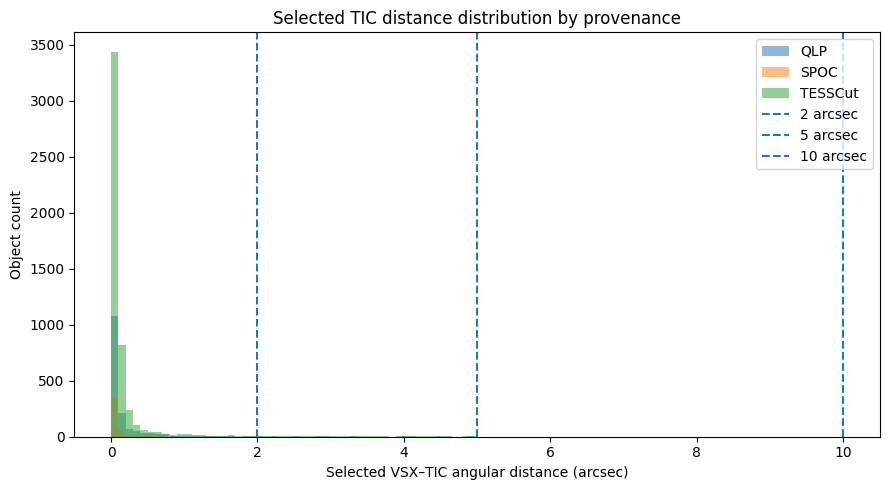

In [20]:
plot_df = analysis_df[np.isfinite(analysis_df["selectedDistanceArcsec"])].copy()

plt.figure(figsize=(9, 5))
for prov, g in plot_df.groupby("provenance"):
    plt.hist(g["selectedDistanceArcsec"], bins=50, alpha=0.5, label=str(prov))
plt.axvline(HIGH_CONF_ARCSEC, linestyle="--", label=f"{HIGH_CONF_ARCSEC:g} arcsec")
plt.axvline(MEDIUM_CONF_ARCSEC, linestyle="--", label=f"{MEDIUM_CONF_ARCSEC:g} arcsec")
plt.axvline(LOW_CONF_ARCSEC, linestyle="--", label=f"{LOW_CONF_ARCSEC:g} arcsec")
plt.xlabel("Selected VSX–TIC angular distance (arcsec)")
plt.ylabel("Object count")
plt.title("Selected TIC distance distribution by provenance")
plt.legend()
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "distance_hist_by_provenance.png", dpi=160)
plt.show()

### 16.5. Candidate-rank analysis

If the selected candidate is often not rank 1, then the pipeline is frequently skipping the nearest TIC candidate to obtain SPOC/QLP availability. That is useful but should be disclosed because it introduces cross-match uncertainty.

In [21]:
rank_table = pd.crosstab(
    analysis_df["provenance"],
    analysis_df["selectedCandidateRank"],
    margins=True,
    dropna=False
)
display(rank_table)
rank_table.to_csv(Path(OUTPUT_DIR) / "selected_candidate_rank_by_provenance.csv")

rank_pct = pd.crosstab(
    analysis_df["provenance"],
    analysis_df["selectedCandidateRank"],
    normalize="index",
    dropna=False
) * 100

display(rank_pct.round(2))
rank_pct.to_csv(Path(OUTPUT_DIR) / "selected_candidate_rank_by_provenance_pct.csv")

selectedCandidateRank,1.0,2.0,3.0,4.0,5.0,NaN,All
provenance,,,,,,,
QLP,1587,10,5,5,5,0,1612
SPOC,467,0,0,0,0,0,467
TESSCut,5034,0,0,0,0,0,5034
NaN,0,1,1,0,0,255,257
All,7088,11,6,5,5,255,7370


selectedCandidateRank,1.0,2.0,3.0,4.0,5.0,NaN
provenance,,,,,,
QLP,98.45,0.62,0.31,0.31,0.31,0.00
SPOC,100.00,0.00,0.00,0.00,0.00,0.00
TESSCut,100.00,0.00,0.00,0.00,0.00,0.00
NaN,0.00,0.39,0.39,0.00,0.00,99.22


### 16.6. TESSCut coordinate-source check

This checks whether TESSCut extraction used TIC coordinates or original VSX coordinates.

For the uploaded downloader logic, TESSCut normally uses the nearest TIC candidate with valid RA/Dec. It uses VSX coordinates only if no TIC candidate has valid coordinates.

In [22]:
tesscut_df = analysis_df[analysis_df["provenance"].astype(str).str.lower().eq("tesscut")].copy()
print("TESSCut rows:", len(tesscut_df))

if len(tesscut_df):
    coord_summary = pd.DataFrame({
        "metric": ["TESSCut used TIC coords", "TESSCut used VSX coords", "TESSCut ambiguous/unknown"],
        "count": [
            int(tesscut_df["tesscutUsedTicCoords"].sum()),
            int(tesscut_df["tesscutUsedVsxCoords"].sum()),
            int((~tesscut_df["tesscutUsedTicCoords"] & ~tesscut_df["tesscutUsedVsxCoords"]).sum()),
        ]
    })
    coord_summary["pct"] = 100 * coord_summary["count"] / len(tesscut_df)
    display(coord_summary)
    coord_summary.to_csv(Path(OUTPUT_DIR) / "tesscut_coordinate_source_summary.csv", index=False)
else:
    print("No TESSCut rows found.")

TESSCut rows: 5034


,metric,count,pct
0,TESSCut used TIC coords,5034,100.0
1,TESSCut used VSX coords,0,0.0
2,TESSCut ambiguous/unknown,0,0.0


### 16.7. Family-level reliability summary

This is especially important for XRAY. If XRAY mappings have larger distances or unusual candidate ranks, then poor XRAY classification may reflect cross-match uncertainty, not only astrophysics or ML weakness.

In [23]:
family_col = "family" if "family" in analysis_df.columns else None

if family_col:
    family_summary = analysis_df.groupby([family_col, "provenance"], dropna=False).apply(summarize_distance).reset_index()
    display(family_summary.sort_values([family_col, "provenance"]))
    family_summary.to_csv(Path(OUTPUT_DIR) / "family_provenance_mapping_summary.csv", index=False)
else:
    print("No family column found.")

,family,provenance,n,available_n,distance_available_n,median_arcsec,p90_arcsec,p95_arcsec,max_arcsec,rank_known_n,rank1_pct_of_known,rank_gt1_pct_of_known,high_conf_pct_of_known_distance,medium_or_worse_pct_of_known_distance,low_or_worse_pct_of_known_distance,very_low_conf_pct_of_known_distance
0,CEPHEID,QLP,168.0,168.0,168.0,0.032246,0.191906,0.444099,4.558883,168.0,98.809524,1.190476,98.809524,1.190476,0.0,0.0
1,CEPHEID,SPOC,29.0,29.0,29.0,0.054857,0.168013,0.485548,0.659346,29.0,100.000000,0.000000,100.000000,0.000000,0.0,0.0
2,CEPHEID,TESSCut,639.0,639.0,639.0,0.030521,0.183291,0.298090,4.412561,639.0,100.000000,0.000000,99.530516,0.469484,0.0,0.0
3,CEPHEID,NaN,164.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
4,CV,QLP,4.0,4.0,4.0,3.768676,4.406014,4.463934,4.521855,4.0,50.000000,50.000000,0.000000,100.000000,0.0,0.0
5,CV,SPOC,66.0,66.0,66.0,0.063851,0.554120,0.673113,4.006005,66.0,100.000000,0.000000,96.969697,3.030303,0.0,0.0
6,CV,TESSCut,525.0,525.0,525.0,0.060881,2.559524,3.409328,4.995207,525.0,100.000000,0.000000,84.761905,15.238095,0.0,0.0
7,CV,NaN,8.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
8,DSCT_SXPHE,QLP,153.0,153.0,153.0,0.018057,0.170921,0.330175,4.516409,153.0,98.692810,1.307190,98.692810,1.307190,0.0,0.0
9,DSCT_SXPHE,SPOC,34.0,34.0,34.0,0.041609,0.131153,0.195937,0.597359,34.0,100.000000,0.000000,100.000000,0.000000,0.0,0.0


,family,n,available_n,distance_available_n,median_arcsec,p90_arcsec,p95_arcsec,max_arcsec,rank_known_n,rank1_pct_of_known,rank_gt1_pct_of_known,high_conf_pct_of_known_distance,medium_or_worse_pct_of_known_distance,low_or_worse_pct_of_known_distance,very_low_conf_pct_of_known_distance
5,LONG_PERIOD,980.0,980.0,980.0,0.080955,0.649278,1.139622,4.808517,980.0,99.795918,0.204082,98.367347,1.632653,0.0,0.0
8,YSO,724.0,724.0,724.0,0.080611,0.322383,0.532358,2.858830,724.0,100.000000,0.000000,99.447514,0.552486,0.0,0.0
7,XRAY,56.0,56.0,56.0,0.077627,1.420715,1.836009,4.468360,56.0,100.000000,0.000000,94.642857,5.357143,0.0,0.0
2,DSCT_SXPHE,953.0,953.0,953.0,0.063945,0.224048,0.591581,4.516409,953.0,99.790136,0.209864,98.426023,1.573977,0.0,0.0
1,CV,595.0,595.0,595.0,0.063168,2.528500,3.412603,4.995207,595.0,99.663866,0.336134,85.546218,14.453782,0.0,0.0
6,RRLYR,976.0,976.0,976.0,0.054246,0.418466,0.714727,4.952769,976.0,99.180328,0.819672,98.565574,1.434426,0.0,0.0
3,ECLIPSING,996.0,996.0,996.0,0.038449,0.248396,0.542828,4.910604,996.0,99.598394,0.401606,99.397590,0.602410,0.0,0.0
0,CEPHEID,836.0,836.0,836.0,0.030965,0.184018,0.323833,4.558883,836.0,99.760766,0.239234,99.401914,0.598086,0.0,0.0
4,ELLIPSOIDAL_ROT,997.0,997.0,997.0,0.019847,0.153727,0.221224,4.633324,997.0,99.498495,0.501505,99.598796,0.401204,0.0,0.0


,family,provenance,n,available_n,distance_available_n,median_arcsec,p90_arcsec,p95_arcsec,max_arcsec,rank_known_n,rank1_pct_of_known,rank_gt1_pct_of_known,high_conf_pct_of_known_distance,medium_or_worse_pct_of_known_distance,low_or_worse_pct_of_known_distance,very_low_conf_pct_of_known_distance
0,CEPHEID,QLP,168.0,168.0,168.0,0.032246,0.191906,0.444099,4.558883,168.0,98.809524,1.190476,98.809524,1.190476,0.0,0.0
1,CEPHEID,SPOC,29.0,29.0,29.0,0.054857,0.168013,0.485548,0.659346,29.0,100.000000,0.000000,100.000000,0.000000,0.0,0.0
2,CEPHEID,TESSCut,639.0,639.0,639.0,0.030521,0.183291,0.298090,4.412561,639.0,100.000000,0.000000,99.530516,0.469484,0.0,0.0
3,CV,QLP,4.0,4.0,4.0,3.768676,4.406014,4.463934,4.521855,4.0,50.000000,50.000000,0.000000,100.000000,0.0,0.0
4,CV,SPOC,66.0,66.0,66.0,0.063851,0.554120,0.673113,4.006005,66.0,100.000000,0.000000,96.969697,3.030303,0.0,0.0
5,CV,TESSCut,525.0,525.0,525.0,0.060881,2.559524,3.409328,4.995207,525.0,100.000000,0.000000,84.761905,15.238095,0.0,0.0
6,DSCT_SXPHE,QLP,153.0,153.0,153.0,0.018057,0.170921,0.330175,4.516409,153.0,98.692810,1.307190,98.692810,1.307190,0.0,0.0
7,DSCT_SXPHE,SPOC,34.0,34.0,34.0,0.041609,0.131153,0.195937,0.597359,34.0,100.000000,0.000000,100.000000,0.000000,0.0,0.0
8,DSCT_SXPHE,TESSCut,766.0,766.0,766.0,0.071398,0.243537,0.699841,4.311165,766.0,100.000000,0.000000,98.302872,1.697128,0.0,0.0
9,ECLIPSING,QLP,174.0,174.0,174.0,0.021857,0.354649,0.812932,4.885086,174.0,97.701149,2.298851,97.126437,2.873563,0.0,0.0


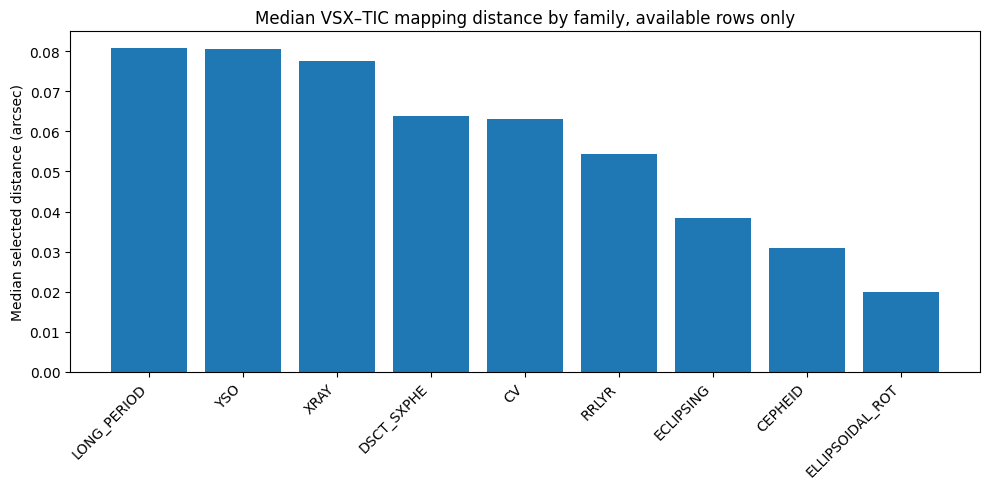

In [24]:
if family_col:
    family_overall = available_df.groupby(family_col, dropna=False).apply(summarize_distance).reset_index()
    family_overall = family_overall.sort_values("median_arcsec", ascending=False)
    display(family_overall)
    family_overall.to_csv(Path(OUTPUT_DIR) / "family_mapping_summary_available_only.csv", index=False)

    # Family x provenance table is useful because XRAY may be small but scientifically important.
    family_prov_summary = available_df.groupby([family_col, "provenance"], dropna=False).apply(summarize_distance).reset_index()
    display(family_prov_summary)
    family_prov_summary.to_csv(Path(OUTPUT_DIR) / "family_by_provenance_mapping_summary_available_only.csv", index=False)

    plt.figure(figsize=(10, 5))
    plt.bar(family_overall[family_col].astype(str), family_overall["median_arcsec"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Median selected distance (arcsec)")
    plt.title("Median VSX–TIC mapping distance by family, available rows only")
    plt.tight_layout()
    plt.savefig(Path(OUTPUT_DIR) / "median_distance_by_family_available_only.png", dpi=160)
    plt.show()


### 16.8. Confidence bucket tables

These tables convert angular distance into easy-to-explain confidence categories.

Suggested interpretation:

- High confidence: very close positional match.
- Medium confidence: plausible match, but worth checking in crowded fields.
- Low confidence: usable but scientifically weaker.
- Very low confidence: should be manually inspected before making strong claims.

In [25]:
bucket_by_prov = pd.crosstab(
    available_df["provenance"],
    available_df["mappingConfidenceBucket"],
    normalize="index"
) * 100
bucket_by_prov = bucket_by_prov.round(2)
display(bucket_by_prov)
bucket_by_prov.to_csv(Path(OUTPUT_DIR) / "confidence_bucket_by_provenance_pct_available_only.csv")

if family_col:
    bucket_by_family = pd.crosstab(
        available_df[family_col],
        available_df["mappingConfidenceBucket"],
        normalize="index"
    ) * 100
    bucket_by_family = bucket_by_family.round(2)
    display(bucket_by_family)
    bucket_by_family.to_csv(Path(OUTPUT_DIR) / "confidence_bucket_by_family_pct_available_only.csv")

# A compact statement that can be copied into notes/paper draft.
known = available_df["selectedDistanceArcsec"].dropna()
if len(known):
    print("Overall available-row positional reliability:")
    print(f"  high confidence ≤ {HIGH_CONF_ARCSEC:g} arcsec: {(known <= HIGH_CONF_ARCSEC).mean() * 100:.2f}%")
    print(f"  medium-or-worse > {HIGH_CONF_ARCSEC:g} arcsec: {(known > HIGH_CONF_ARCSEC).mean() * 100:.2f}%")
    print(f"  low-or-worse > {MEDIUM_CONF_ARCSEC:g} arcsec: {(known > MEDIUM_CONF_ARCSEC).mean() * 100:.2f}%")
    print(f"  maximum selected distance: {known.max():.3f} arcsec")


mappingConfidenceBucket,high_≤2arcsec,medium_≤5arcsec
provenance,,
QLP,97.77,2.23
SPOC,99.57,0.43
TESSCut,97.72,2.28


mappingConfidenceBucket,high_≤2arcsec,medium_≤5arcsec
family,,
CEPHEID,99.40,0.60
CV,85.55,14.45
DSCT_SXPHE,98.43,1.57
ECLIPSING,99.40,0.60
ELLIPSOIDAL_ROT,99.60,0.40
LONG_PERIOD,98.37,1.63
RRLYR,98.57,1.43
XRAY,94.64,5.36
YSO,99.45,0.55


Overall available-row positional reliability:
  high confidence ≤ 2 arcsec: 97.85%
  medium-or-worse > 2 arcsec: 2.15%
  low-or-worse > 5 arcsec: 0.00%
  maximum selected distance: 4.995 arcsec


### 16.9. Duplicate TIC mapping check

If multiple VSX objects map to the same TIC, that can mean:

1. The same physical object appears under multiple VSX records.
2. The field is crowded and the mapping is ambiguous.
3. The pipeline is over-selecting a nearby TIC because it has available TESS products.

This does not automatically mean the mapping is wrong, but it deserves review.

In [26]:
dup = (
    analysis_df.dropna(subset=["selectedTicId"])
    .groupby("selectedTicId")
    .agg(
        n_vsx=("selectedTicId", "size"),
        families=("family", lambda x: sorted(set(map(str, x.dropna())))) if "family" in analysis_df.columns else ("selectedTicId", "size"),
        provenances=("provenance", lambda x: sorted(set(map(str, x.dropna())))),
        vsx_ids=("VSXId", lambda x: list(x.dropna().astype(str).head(10))) if "VSXId" in analysis_df.columns else ("selectedTicId", "size"),
        median_distance_arcsec=("selectedDistanceArcsec", "median"),
    )
    .reset_index()
    .query("n_vsx > 1")
    .sort_values(["n_vsx", "median_distance_arcsec"], ascending=[False, False])
)

print("Duplicate selected TIC count:", len(dup))
display(dup.head(50))
dup.to_csv(Path(OUTPUT_DIR) / "duplicate_selected_tic_mappings.csv", index=False)

Duplicate selected TIC count: 0


,selectedTicId,n_vsx,families,provenances,vsx_ids,median_distance_arcsec


### 16.10. Positional ambiguity analysis

Small VSX–TIC separation is good evidence, but it is not complete proof of a correct counterpart. In crowded fields, two TIC candidates can both be close to the VSX position. This section flags rows where a nearby competing TIC candidate could make the mapping less secure.

The two main ambiguity indicators are:

- `hasMultipleCloseCandidates`: at least two TIC candidates within `AMBIGUOUS_WITHIN_ARCSEC` of the VSX position.
- `hasCloseCompetitor`: the second-nearest candidate is within `CLOSE_COMPETITOR_RATIO` times the nearest-candidate distance.

These flags do not prove the mapping is wrong. They identify rows worth reviewing before making strong astrophysical claims.

In [27]:
ambiguity_df = available_df.copy()

ambiguity_summary = ambiguity_df.groupby("provenance", dropna=False).agg(
    n=("provenance", "size"),
    median_selected_distance_arcsec=("selectedDistanceArcsec", "median"),
    pct_multiple_close_candidates=("hasMultipleCloseCandidates", lambda x: 100 * x.fillna(False).mean()),
    pct_close_competitor=("hasCloseCompetitor", lambda x: 100 * x.fillna(False).mean()),
    pct_selected_not_nearest=("selectedNotNearest", lambda x: 100 * x.fillna(False).mean()),
    median_candidates_within_radius=("candidatesWithinAmbiguousRadius", "median"),
).reset_index()

display(ambiguity_summary.round(3))
ambiguity_summary.to_csv(Path(OUTPUT_DIR) / "positional_ambiguity_by_provenance_available_only.csv", index=False)

if family_col:
    ambiguity_family_summary = ambiguity_df.groupby([family_col, "provenance"], dropna=False).agg(
        n=("provenance", "size"),
        median_selected_distance_arcsec=("selectedDistanceArcsec", "median"),
        pct_multiple_close_candidates=("hasMultipleCloseCandidates", lambda x: 100 * x.fillna(False).mean()),
        pct_close_competitor=("hasCloseCompetitor", lambda x: 100 * x.fillna(False).mean()),
        pct_selected_not_nearest=("selectedNotNearest", lambda x: 100 * x.fillna(False).mean()),
    ).reset_index()
    display(ambiguity_family_summary.round(3))
    ambiguity_family_summary.to_csv(Path(OUTPUT_DIR) / "positional_ambiguity_by_family_provenance_available_only.csv", index=False)

ambiguous_rows = ambiguity_df[
    ambiguity_df["hasMultipleCloseCandidates"].fillna(False)
    | ambiguity_df["hasCloseCompetitor"].fillna(False)
    | ambiguity_df["selectedNotNearest"].fillna(False)
].copy()

ambiguous_cols = [c for c in [
    "VSXId", "VSXName", "family", "VSXType", "provenance", "selectedTicId", "selectedCandidateRank",
    "selectedDistanceArcsec", "nearestCandidateDistanceArcsec", "secondCandidateDistanceArcsec",
    "closeCompetitorRatio", "candidatesWithinAmbiguousRadius", "hasCloseCompetitor",
    "hasMultipleCloseCandidates", "selectedNotNearest", "mappingConfidenceBucket", "rawLightCurvePath"
] if c in ambiguous_rows.columns]

print("Available rows with at least one positional-ambiguity flag:", len(ambiguous_rows))
display(ambiguous_rows.sort_values(
    ["selectedNotNearest", "hasMultipleCloseCandidates", "hasCloseCompetitor", "selectedDistanceArcsec"],
    ascending=[False, False, False, False]
)[ambiguous_cols].head(100))
ambiguous_rows[ambiguous_cols].to_csv(Path(OUTPUT_DIR) / "positional_ambiguity_flagged_rows_available_only.csv", index=False)


,provenance,n,median_selected_distance_arcsec,pct_multiple_close_candidates,pct_close_competitor,pct_selected_not_nearest,median_candidates_within_radius
0,QLP,1612,0.057,37.965,2.543,1.551,1.0
1,SPOC,467,0.047,21.842,2.141,0.000,1.0
2,TESSCut,5034,0.055,48.192,3.854,0.000,1.0


,family,provenance,n,median_selected_distance_arcsec,pct_multiple_close_candidates,pct_close_competitor,pct_selected_not_nearest
0,CEPHEID,QLP,168,0.032,52.381,0.595,1.190
1,CEPHEID,SPOC,29,0.055,48.276,0.000,0.000
2,CEPHEID,TESSCut,639,0.031,72.300,3.130,0.000
3,CV,QLP,4,3.769,50.000,0.000,50.000
4,CV,SPOC,66,0.064,30.303,3.030,0.000
5,CV,TESSCut,525,0.061,43.048,14.095,0.000
6,DSCT_SXPHE,QLP,153,0.018,38.562,1.961,1.307
7,DSCT_SXPHE,SPOC,34,0.042,17.647,0.000,0.000
8,DSCT_SXPHE,TESSCut,766,0.071,51.175,3.655,0.000
9,ECLIPSING,QLP,174,0.022,39.080,3.448,2.299


Available rows with at least one positional-ambiguity flag: 3140


,VSXId,VSXName,family,VSXType,provenance,selectedTicId,selectedCandidateRank,selectedDistanceArcsec,nearestCandidateDistanceArcsec,secondCandidateDistanceArcsec,closeCompetitorRatio,candidatesWithinAmbiguousRadius,hasCloseCompetitor,hasMultipleCloseCandidates,selectedNotNearest,mappingConfidenceBucket,rawLightCurvePath
2676,CoRoT 206155416,CoRoT 206155416,ECLIPSING,EA,QLP,1775940542,2.0,2.759353,1.804898,2.759353,1.528814,5,True,True,True,medium_≤5arcsec,TESSCache/VSX_CoRoT_206155416_TIC_1775940542_QLP_raw.fits
5588,Terz V 3667,Terz V 3667,LONG_PERIOD,LPV,QLP,45078315,2.0,2.575439,2.112599,2.575439,1.219086,2,True,True,True,medium_≤5arcsec,TESSCache/VSX_Terz_V_3667_TIC_45078315_QLP_raw.fits
5997,Gaia DR3 4261530464528831360,Gaia DR3 4261530464528831360,RRLYR,RRAB,QLP,7305136,5.0,4.952769,0.080188,2.011394,25.083627,5,False,True,True,medium_≤5arcsec,TESSCache/VSX_Gaia_DR3_4261530464528831360_TIC_7305136_QLP_raw.fits
2631,ZTF J191102.55+140521.7,ZTF J191102.55+140521.7,ECLIPSING,EA,QLP,1798231255,2.0,4.885086,0.043561,4.885086,112.142390,2,False,True,True,medium_≤5arcsec,TESSCache/VSX_ZTF_J191102.55+140521.7_TIC_1798231255_QLP_raw.fits
5397,NSVS 13963811,NSVS 13963811,LONG_PERIOD,LPV,QLP,57814206,4.0,4.808517,1.515315,4.149441,2.738335,4,False,True,True,medium_≤5arcsec,TESSCache/VSX_NSVS_13963811_TIC_57814206_QLP_raw.fits
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1364,000-BPR-548,Gaia23clt,CV,UG,TESSCut,221703663,1.0,2.039053,2.039053,3.391167,1.663109,3,True,True,False,medium_≤5arcsec,TESSCache/VSX_000-BPR-548_TIC_221703663_TESSCut_raw.fits
1486,OGLE-BLG-DN-0556,OGLE-BLG-DN-0556,CV,UG,TESSCut,1567544262,1.0,2.037563,2.037563,2.289104,1.123452,4,True,True,False,medium_≤5arcsec,TESSCache/VSX_OGLE-BLG-DN-0556_TIC_1567544262_TESSCut_raw.fits
1381,OGLE-BLG-DN-1026,OGLE-BLG-DN-1026,CV,UG,TESSCut,1602355853,1.0,2.025750,2.025750,3.192674,1.576045,3,True,True,False,medium_≤5arcsec,TESSCache/VSX_OGLE-BLG-DN-1026_TIC_1602355853_TESSCut_raw.fits
1442,OGLE-BLG-DN-0443,OGLE-BLG-DN-0443,CV,UG,TESSCut,1603919061,1.0,2.003044,2.003044,2.126076,1.061423,4,True,True,False,medium_≤5arcsec,TESSCache/VSX_OGLE-BLG-DN-0443_TIC_1603919061_TESSCut_raw.fits


### 10b. Objects for optional manual review, not automatically "high-risk"

This section used to label many rows as **high-risk**. That wording is too strong for this project because the v3 results showed that ambiguity flags are common but are **not statistically associated with RF errors**.

The purpose of this table is now narrower:

> Identify a small, ranked set of objects that are worth optional manual inspection if you want extra reviewer-proof evidence.

These objects should not be treated as failed mappings unless visual inspection or external catalog checks support that interpretation.

In [28]:
optional_review = available_df.copy()

# ---------------------------------------------------------------------
# Safety: Section 10b should work even if earlier ambiguity diagnostics
# were skipped or column names differ between notebook versions.
# ---------------------------------------------------------------------
if "hasMultipleCloseCandidates" not in optional_review.columns:
    optional_review["hasMultipleCloseCandidates"] = False
if "hasCloseCompetitor" not in optional_review.columns:
    optional_review["hasCloseCompetitor"] = False
if "selectedNotNearest" not in optional_review.columns:
    optional_review["selectedNotNearest"] = optional_review.get("selectedCandidateRank", pd.Series(index=optional_review.index, dtype=float)).fillna(1).gt(1)
if "candidatesWithinAmbiguousRadius" not in optional_review.columns:
    optional_review["candidatesWithinAmbiguousRadius"] = np.nan
if "closeCompetitorRatio" not in optional_review.columns:
    optional_review["closeCompetitorRatio"] = np.nan

# Backward-compatible aliases for older output/table names.
optional_review["multipleCloseCandidates"] = optional_review["hasMultipleCloseCandidates"].fillna(False)
optional_review["nearestCompetitorDistanceRatio"] = optional_review["closeCompetitorRatio"]
optional_review["nCandidatesWithin5Arcsec"] = optional_review["candidatesWithinAmbiguousRadius"]

if "nCandidatesWithin2Arcsec" not in optional_review.columns:
    # Compute a simple within-2-arcsec count from ticCandidates when possible.
    def count_candidates_within(row, radius_arcsec=2.0):
        candidates = sorted_candidates(row.get("ticCandidates"))
        distances = [angular_distance_arcsec_from_candidate(c) for c in candidates]
        distances = [d for d in distances if np.isfinite(d)]
        return int(np.sum(np.asarray(distances) <= radius_arcsec)) if distances else 0
    optional_review["nCandidatesWithin2Arcsec"] = optional_review.apply(count_candidates_within, axis=1)

optional_review["reviewPriorityScore"] = 0.0

# Distance-based review priority. These thresholds are intentionally conservative.
# In your v3 results TESSCut had no rows beyond 5 arcsec, so this should mostly
# identify unusual non-TESSCut rows or future data-quality issues.
optional_review["reviewPriorityScore"] += np.where(optional_review["selectedDistanceArcsec"] > 5, 5.0, 0.0)
optional_review["reviewPriorityScore"] += np.where(optional_review["selectedDistanceArcsec"] > 2, 2.0, 0.0)
optional_review["reviewPriorityScore"] += np.where(optional_review["selectedDistanceArcsec"] > 1, 1.0, 0.0)

# Non-rank-1 selected candidates are worth checking, but not automatically suspicious.
optional_review["reviewPriorityScore"] += np.where(optional_review["selectedCandidateRank"].fillna(1) > 1, 1.5, 0.0)

# Candidate crowding / ambiguity indicators.
# These are common and were not statistically associated with RF errors in your v3 run,
# so they receive small weights and should be interpreted as optional-review flags only.
optional_review["reviewPriorityScore"] += np.where(optional_review["hasMultipleCloseCandidates"].fillna(False), 1.0, 0.0)
optional_review["reviewPriorityScore"] += np.where(optional_review["hasCloseCompetitor"].fillna(False), 1.0, 0.0)
optional_review["reviewPriorityScore"] += np.where(optional_review["selectedNotNearest"].fillna(False), 1.0, 0.0)

# XRAY is flagged for scientific caution because the class behaves unusually in the RF model,
# but this is not evidence by itself that the mapping is wrong.
if "family" in optional_review.columns:
    optional_review["reviewPriorityScore"] += np.where(optional_review["family"].astype(str).str.upper().eq("XRAY"), 1.0, 0.0)

review_cols = [
    c for c in [
        "VSXId", "VSXName", "family", "VSXType", "provenance", "selectedTicId",
        "selectedCandidateRank", "selectedDistanceArcsec", "nCandidates",
        "nCandidatesWithin2Arcsec", "nCandidatesWithin5Arcsec", "nearestCompetitorDistanceRatio",
        "hasMultipleCloseCandidates", "hasCloseCompetitor", "selectedNotNearest",
        "reviewPriorityScore", "raDeg", "decDeg", "selectedRaDeg", "selectedDecDeg", "lightCurvePath"
    ] if c in optional_review.columns
]

optional_review = optional_review.sort_values(
    ["reviewPriorityScore", "selectedDistanceArcsec"],
    ascending=[False, False]
)

manual_review_path = Path(OUTPUT_DIR) / "optional_manual_review_objects.csv"
optional_review[review_cols].head(200).to_csv(manual_review_path, index=False)

print("Optional manual-review table saved to:", manual_review_path)
print("Rows with reviewPriorityScore > 0:", int((optional_review["reviewPriorityScore"] > 0).sum()))
print("Important interpretation: these are not failed mappings; they are only prioritized candidates for optional inspection.")
display(optional_review[review_cols].head(30))


Optional manual-review table saved to: /data/projects/TESS-research/mapping_reliability/output/optional_manual_review_objects.csv
Rows with reviewPriorityScore > 0: 3263
Important interpretation: these are not failed mappings; they are only prioritized candidates for optional inspection.


,VSXId,VSXName,family,VSXType,provenance,selectedTicId,selectedCandidateRank,selectedDistanceArcsec,nCandidatesWithin2Arcsec,nCandidatesWithin5Arcsec,nearestCompetitorDistanceRatio,hasMultipleCloseCandidates,hasCloseCompetitor,selectedNotNearest,reviewPriorityScore,raDeg,decDeg,lightCurvePath
2676,CoRoT 206155416,CoRoT 206155416,ECLIPSING,EA,QLP,1775940542,2.0,2.759353,1,5,1.528814,True,True,True,7.5,285.359190,-2.052360,TESSCache/VSX_CoRoT_206155416_TIC_1775940542_QLP_standardized.fits
5588,Terz V 3667,Terz V 3667,LONG_PERIOD,LPV,QLP,45078315,2.0,2.575439,0,2,1.219086,True,True,True,7.5,257.699500,-30.787780,TESSCache/VSX_Terz_V_3667_TIC_45078315_QLP_standardized.fits
5997,Gaia DR3 4261530464528831360,Gaia DR3 4261530464528831360,RRLYR,RRAB,QLP,7305136,5.0,4.952769,1,5,25.083627,True,False,True,6.5,288.231560,-1.257190,TESSCache/VSX_Gaia_DR3_4261530464528831360_TIC_7305136_QLP_standardized.fits
2631,ZTF J191102.55+140521.7,ZTF J191102.55+140521.7,ECLIPSING,EA,QLP,1798231255,2.0,4.885086,1,2,112.142390,True,False,True,6.5,287.760630,14.089380,TESSCache/VSX_ZTF_J191102.55+140521.7_TIC_1798231255_QLP_standardized.fits
5397,NSVS 13963811,NSVS 13963811,LONG_PERIOD,LPV,QLP,57814206,4.0,4.808517,1,4,2.738335,True,False,True,6.5,284.106810,-2.628920,TESSCache/VSX_NSVS_13963811_TIC_57814206_QLP_standardized.fits
3896,Gaia DR3 372805845648962688,Gaia DR3 372805845648962688,ELLIPSOIDAL_ROT,RS,QLP,186363996,2.0,4.633324,1,2,491.246703,True,False,True,6.5,18.314170,41.539960,TESSCache/VSX_Gaia_DR3_372805845648962688_TIC_186363996_QLP_standardized.fits
895,OGLE-GAL-ACEP-020,OGLE-GAL-ACEP-020,CEPHEID,ACEP,QLP,1419860808,5.0,4.558883,1,5,43.277331,True,False,True,6.5,269.553380,-30.881620,TESSCache/VSX_OGLE-GAL-ACEP-020_TIC_1419860808_QLP_standardized.fits
1452,ZTF18abqcqja,ZTF18abqcqja,CV,UG,QLP,1878809882,5.0,4.521855,1,5,67.026790,True,False,True,6.5,299.586120,37.294800,TESSCache/VSX_ZTF18abqcqja_TIC_1878809882_QLP_standardized.fits
1709,V1795 Cen,V1795 Cen,DSCT_SXPHE,SXPHE,QLP,1048151950,4.0,4.516409,2,5,8.541862,True,False,True,6.5,201.958460,-47.354470,TESSCache/VSX_V1795_Cen_TIC_1048151950_QLP_standardized.fits
3720,Gaia DR3 5939234747228543616,Gaia DR3 5939234747228543616,ELLIPSOIDAL_ROT,ELL,QLP,55622146,3.0,4.484326,2,4,148.391318,True,False,True,6.5,252.718400,-48.661730,TESSCache/VSX_Gaia_DR3_5939234747228543616_TIC_55622146_QLP_standardized.fits


### 16.11. Automatic interpretation checks

This cell generates conservative interpretation language. It does **not** claim that all mappings are correct. Instead, it asks whether there is evidence for **large-scale** cross-match failure that could plausibly explain the TESSCut RF degradation.

Recommended wording standard:

- Avoid: "TESSCut mappings are correct."
- Prefer: "The mapping diagnostics show no evidence of widespread cross-match failure."

In [29]:
def pct(x):
    return 100.0 * float(x)

known_all = available_df["selectedDistanceArcsec"].dropna()
tess_known = available_df.loc[available_df["provenance"].astype(str).str.lower().eq("tesscut"), "selectedDistanceArcsec"].dropna()
rank_known = available_df["selectedCandidateRank"].dropna()

print("Interpretation helper:")
if len(known_all):
    overall_high = (known_all <= HIGH_CONF_ARCSEC).mean()
    overall_low_or_worse = (known_all > MEDIUM_CONF_ARCSEC).mean()
    print(f"- Overall, {pct(overall_high):.2f}% of available rows are within {HIGH_CONF_ARCSEC:g} arcsec.")
    print(f"- Overall, {pct(overall_low_or_worse):.2f}% of available rows are worse than {MEDIUM_CONF_ARCSEC:g} arcsec.")
if len(tess_known):
    tess_high = (tess_known <= HIGH_CONF_ARCSEC).mean()
    tess_low_or_worse = (tess_known > MEDIUM_CONF_ARCSEC).mean()
    print(f"- TESSCut, {pct(tess_high):.2f}% of available rows are within {HIGH_CONF_ARCSEC:g} arcsec.")
    print(f"- TESSCut, {pct(tess_low_or_worse):.2f}% of available rows are worse than {MEDIUM_CONF_ARCSEC:g} arcsec.")
if len(rank_known):
    print(f"- {pct((rank_known == 1).mean()):.2f}% of available rows selected the nearest candidate by angular distance.")

if {"hasMultipleCloseCandidates", "hasCloseCompetitor", "selectedNotNearest"}.issubset(available_df.columns):
    any_ambiguous = (
        available_df["hasMultipleCloseCandidates"].fillna(False)
        | available_df["hasCloseCompetitor"].fillna(False)
        | available_df["selectedNotNearest"].fillna(False)
    )
    print(f"- {pct(any_ambiguous.mean()):.2f}% of available rows have at least one ambiguity flag.")

print("\nSuggested conservative conclusion:")
print("The positional statistics can show whether there is evidence for widespread cross-match failure, but they should not be used to prove that every mapping is correct.")
print("If the high-confidence fraction is large and ambiguity/outlier rows are rare, the defensible statement is: no obvious large-scale VSX–TIC matching failure is visible in these diagnostics.")
print("The stronger claim—that TESSCut RF degradation is mainly due to provenance/extraction rather than mapping errors—requires the optional prediction-join test below.")

print("\nRecommended next step:")
print("Join this table to ML predictions and test whether incorrect predictions have larger distances, more non-rank-1 selections, or more ambiguity flags. If not, provenance/extraction effects become the stronger explanation.")


Interpretation helper:
- Overall, 97.85% of available rows are within 2 arcsec.
- Overall, 0.00% of available rows are worse than 5 arcsec.
- TESSCut, 97.72% of available rows are within 2 arcsec.
- TESSCut, 0.00% of available rows are worse than 5 arcsec.
- 99.65% of available rows selected the nearest candidate by angular distance.
- 44.14% of available rows have at least one ambiguity flag.

Suggested conservative conclusion:
The positional statistics can show whether there is evidence for widespread cross-match failure, but they should not be used to prove that every mapping is correct.
If the high-confidence fraction is large and ambiguity/outlier rows are rare, the defensible statement is: no obvious large-scale VSX–TIC matching failure is visible in these diagnostics.
The stronger claim—that TESSCut RF degradation is mainly due to provenance/extraction rather than mapping errors—requires the optional prediction-join test below.

Recommended next step:
Join this table to ML predi

### 16.12. Optional: join with ML prediction results

Use this only if you have a prediction parquet with one row per object and columns such as true label, predicted label, VSX ID, TIC ID, or light-curve path.

Goal:

> Test whether misclassified objects have weaker VSX–TIC mapping confidence than correctly classified objects.

In [30]:
if PREDICTION_PARQUET is None:
    print("Skipping prediction join because PREDICTION_PARQUET is None.")
else:
    pred = pd.read_parquet(PREDICTION_PARQUET)
    print("Prediction rows:", len(pred))
    print("Prediction columns:", list(pred.columns))
    display(pred.head(3))

    # Try likely join keys in priority order.
    join_key = None
    for key in ["VSXId", "rawLightCurvePath", "lightCurvePath", "selectedTicId", "ticId", "TICId"]:
        if key in analysis_df.columns and key in pred.columns:
            join_key = key
            break

    if join_key is None:
        raise ValueError("Could not find a shared join key. Add/rename a common key such as VSXId or rawLightCurvePath.")

    print("Joining on:", join_key)

    mapping_cols = [c for c in [
        join_key, "provenance", "family", "selectedDistanceArcsec", "selectedCandidateRank",
        "mappingConfidenceBucket", "hasCloseCompetitor", "hasMultipleCloseCandidates",
        "selectedNotNearest", "candidatesWithinAmbiguousRadius", "closeCompetitorRatio"
    ] if c in analysis_df.columns]

    joined = pred.merge(
        analysis_df[mapping_cols].drop_duplicates(subset=[join_key]),
        on=join_key,
        how="left",
        suffixes=("", "_mapping")
    )

    # Try to infer correctness column.
    if "RandomForestCorrect" not in joined.columns:
        label_pairs = [
            ("true_label", "pred_label"),
            ("y_true", "y_pred"),
            ("TrueLabel", "PredictedLabel"),
            ("Actual", "Predicted"),
            ("family", "prediction"),
            ("family", "predicted_family"),
        ]
        for true_col, pred_col in label_pairs:
            if true_col in joined.columns and pred_col in joined.columns:
                joined["correct"] = joined[true_col].astype(str).eq(joined[pred_col].astype(str))
                print("Created correctness from", true_col, pred_col)
                break

    if "RandomForestCorrect" not in joined.columns:
        raise ValueError("Could not infer correctness. Add a boolean column named 'RandomForestCorrect' or update label column names.")

    joined["RandomForestCorrect"] = joined["RandomForestCorrect"].astype(bool)
    joined["anyAmbiguityFlag"] = False
    for c in ["hasCloseCompetitor", "hasMultipleCloseCandidates", "selectedNotNearest"]:
        if c in joined.columns:
            joined["anyAmbiguityFlag"] = joined["anyAmbiguityFlag"] | joined[c].fillna(False).astype(bool)

    display(joined.head())
    joined.to_parquet(Path(OUTPUT_DIR) / "predictions_joined_to_mapping_reliability.parquet", index=False)

    correctness_summary = joined.groupby("RandomForestCorrect").agg(
        n=("RandomForestCorrect", "size"),
        median_distance_arcsec=("selectedDistanceArcsec", "median"),
        mean_distance_arcsec=("selectedDistanceArcsec", "mean"),
        p90_distance_arcsec=("selectedDistanceArcsec", lambda x: x.dropna().quantile(0.90)),
        rank_gt1_pct=("selectedCandidateRank", lambda x: 100 * x.gt(1).mean()),
        ambiguity_flag_pct=("anyAmbiguityFlag", lambda x: 100 * x.fillna(False).mean()),
    ).reset_index()
    display(correctness_summary)
    correctness_summary.to_csv(Path(OUTPUT_DIR) / "prediction_correctness_vs_mapping_summary.csv", index=False)

    bucket_vs_correct = pd.crosstab(joined["mappingConfidenceBucket"], joined["RandomForestCorrect"], normalize="index") * 100
    display(bucket_vs_correct.round(2))
    bucket_vs_correct.to_csv(Path(OUTPUT_DIR) / "confidence_bucket_vs_prediction_correctness_pct.csv")

    if "provenance" in joined.columns:
        prov_correctness_summary = joined.groupby(["provenance", "RandomForestCorrect"], dropna=False).agg(
            n=("RandomForestCorrect", "size"),
            median_distance_arcsec=("selectedDistanceArcsec", "median"),
            rank_gt1_pct=("selectedCandidateRank", lambda x: 100 * x.gt(1).mean()),
            ambiguity_flag_pct=("anyAmbiguityFlag", lambda x: 100 * x.fillna(False).mean()),
        ).reset_index()
        display(prov_correctness_summary)
        prov_correctness_summary.to_csv(Path(OUTPUT_DIR) / "prediction_correctness_vs_mapping_by_provenance.csv", index=False)

    # Statistical tests: do incorrect predictions have weaker mapping confidence?
    print("\nStatistical tests: correct vs incorrect mapping confidence")
    test_rows = []
    correct_dist = joined.loc[joined["RandomForestCorrect"], "selectedDistanceArcsec"].dropna()
    wrong_dist = joined.loc[~joined["RandomForestCorrect"], "selectedDistanceArcsec"].dropna()

    if SCIPY_AVAILABLE and len(correct_dist) >= 3 and len(wrong_dist) >= 3:
        # Mann-Whitney tests whether one group tends to have larger distances; KS checks distributional difference.
        mw = mannwhitneyu(wrong_dist, correct_dist, alternative="greater")
        ks = ks_2samp(wrong_dist, correct_dist, alternative="two-sided")
        test_rows.extend([
            {"test": "Mann-Whitney U: wrong distances > correct distances", "statistic": mw.statistic, "p_value": mw.pvalue, "interpretation": "Small p suggests misclassified rows have larger mapping distances."},
            {"test": "Kolmogorov-Smirnov: wrong vs correct distance distributions", "statistic": ks.statistic, "p_value": ks.pvalue, "interpretation": "Small p suggests different distance distributions."},
        ])
    else:
        print("Distance tests skipped: scipy unavailable or insufficient correct/incorrect rows with distances.")

    if SCIPY_AVAILABLE:
        for flag_col in ["selectedNotNearest", "hasCloseCompetitor", "hasMultipleCloseCandidates", "anyAmbiguityFlag"]:
            if flag_col not in joined.columns:
                continue
            tab = pd.crosstab(joined[flag_col].fillna(False).astype(bool), joined["RandomForestCorrect"])
            if tab.shape == (2, 2):
                chi2, p, dof, expected = chi2_contingency(tab)
                test_rows.append({
                    "test": f"Chi-square: {flag_col} vs correctness",
                    "statistic": chi2,
                    "p_value": p,
                    "interpretation": "Small p suggests this mapping-risk flag is associated with classification errors.",
                })
    else:
        print("Flag association tests skipped because scipy is unavailable.")

    tests_df = pd.DataFrame(test_rows)
    if len(tests_df):
        display(tests_df)
        tests_df.to_csv(Path(OUTPUT_DIR) / "mapping_confidence_vs_prediction_statistical_tests.csv", index=False)

    print("\nHow to read this section:")
    print("- If wrong predictions do not have larger distances or more ambiguity flags, mapping error is less likely to explain TESSCut RF weakness.")
    print("- If wrong predictions do have larger distances or more ambiguity flags, the paper should acknowledge cross-match uncertainty as a contributor.")


Prediction rows: 1067
Prediction columns: ['FeatureStatus', 'FeatureError', 'family', 'VSXType', 'VSXId', 'lightCurvePath', 'rawLightCurvePath', 'QualityLabel', 'QualityScore', 'Provenance', 'ProvenanceScore', 'OriginalFluxMedian', 'OriginalFluxStd', 'OriginalFluxSnr', 'LowSnr', 'LowQualityLightCurve', 'CadenceCount', 'TimeSpanDays', 'MedianCadenceDays', 'FluxMean', 'FluxStd', 'FluxVariance', 'FluxMedian', 'FluxMad', 'FluxMin', 'FluxMax', 'FluxP01', 'FluxP05', 'FluxP10', 'FluxP25', 'FluxP75', 'FluxP90', 'FluxP95', 'FluxP99', 'FluxIqr', 'FluxAmplitude', 'FluxPercentAmplitude95To5', 'FluxPercentAmplitude90To10', 'FluxSkewness', 'FluxKurtosis', 'TailUpper', 'TailLower', 'TailAsymmetry', 'TailRatio', 'EtaVonNeumann', 'MaxAbsSlope', 'MedianAbsSuccessiveDiff', 'FractionBeyond1Std', 'FractionBeyond2Std', 'LsBestPeriod', 'LsBestFrequency', 'LsMaxPower', 'LsFalseAlarmProbability', 'LsPeriod2', 'LsPeriod3', 'LsPower2', 'LsPower3', 'LsPowerRatio21', 'LsPowerRatio31', 'LsPeriodRatio21', 'LsPeriodR

,FeatureStatus,FeatureError,family,VSXType,VSXId,lightCurvePath,rawLightCurvePath,QualityLabel,QualityScore,Provenance,ProvenanceScore,OriginalFluxMedian,OriginalFluxStd,OriginalFluxSnr,LowSnr,LowQualityLightCurve,CadenceCount,TimeSpanDays,MedianCadenceDays,FluxMean,FluxStd,FluxVariance,FluxMedian,FluxMad,FluxMin,FluxMax,FluxP01,FluxP05,FluxP10,FluxP25,FluxP75,FluxP90,FluxP95,FluxP99,FluxIqr,FluxAmplitude,FluxPercentAmplitude95To5,FluxPercentAmplitude90To10,FluxSkewness,FluxKurtosis,TailUpper,TailLower,TailAsymmetry,TailRatio,EtaVonNeumann,MaxAbsSlope,MedianAbsSuccessiveDiff,FractionBeyond1Std,FractionBeyond2Std,LsBestPeriod,LsBestFrequency,LsMaxPower,LsFalseAlarmProbability,LsPeriod2,LsPeriod3,LsPower2,LsPower3,LsPowerRatio21,LsPowerRatio31,LsPeriodRatio21,LsPeriodRatio31,PhaseCurveStd,PhaseCurveRange,PhaseCurveSmoothness,PhasePeakPhase,PhaseTroughPhase,PhasePeakToTroughPhaseDelta,LsTopPeriod1,LsTopFrequency1,LsTopPower1,LsTopPeriod2,LsTopPeriod3,LsTopPower2,LsTopPower3,LsTopFrequency2,LsTopFrequency3,LsFrequencyRatio21,LsFrequencyRatio31,LsPeakPowerGap12,LsPeakPowerGap23,LsLogFalseAlarmProbability,LsNegativeLog10FalseAlarmProbability,LsHasReliableFap,Split,ActualFamily,LogisticRegressionPrediction,RandomForestPrediction,LogisticRegressionCorrect,RandomForestCorrect
0,ok,NaN,CEPHEID,DCEPS,OGLE-GD-CEP-0531,TESSCache/VSX_OGLE-GD-CEP-0531_TIC_457601129_QLP_standardized.fits,TESSCache/VSX_OGLE-GD-CEP-0531_TIC_457601129_QLP_raw.fits,clean,0,QLP,1.0,1.0,0.078925,12.670327,False,False,50520.0,2504.326775,0.002315,0.062681,1.0,1.0,0.0,0.765911,-12.388691,16.418224,-1.691967,-1.335806,-1.120833,-0.710330,0.837848,1.302867,1.499377,1.790574,1.548179,28.806915,2.835183,2.423700,1.728873,21.916410,1.499377,1.335806,0.163571,1.122451,0.045680,1771.619706,0.091166,0.334204,0.005622,3.040548,0.328888,0.679100,0.000000e+00,3.040179,3.040917,0.664363,0.664349,0.978298,0.978278,0.999879,1.000121,0.829565,2.316877,0.262664,0.125162,0.625063,0.499900,3.040548,0.328888,0.679100,3.040179,3.040917,0.664363,0.664349,0.328928,0.328848,1.000121,0.999879,0.014738,0.000013,-690.775528,300.000000,1,test,CEPHEID,CEPHEID,CEPHEID,True,True
1,ok,NaN,ELLIPSOIDAL_ROT,ROT,Gaia DR3 401195682555863168,TESSCache/VSX_Gaia_DR3_401195682555863168_TIC_196474173_TESSCut_standardized.fits,TESSCache/VSX_Gaia_DR3_401195682555863168_TIC_196474173_TESSCut_raw.fits,clean,0,TESSCut,2.0,1.0,0.853412,1.171767,True,True,44706.0,1871.344781,0.002315,0.188840,1.0,1.0,0.0,0.027372,-0.073086,35.647293,-0.056840,-0.053754,-0.043471,-0.024889,0.030922,0.383954,0.708201,4.736012,0.055811,35.720379,0.761955,0.427425,13.633616,302.261982,0.708201,0.053754,0.654446,13.174783,0.022845,832.508308,0.001526,0.030868,0.022100,14.360335,0.069636,0.121607,0.000000e+00,14.945238,14.933312,0.120674,0.117219,0.992328,0.963921,1.040730,1.039900,0.067093,0.264056,0.051505,0.675098,0.173164,0.498066,14.360335,0.069636,0.121607,14.945238,14.933312,0.120674,0.117219,0.066911,0.066964,0.960864,0.961631,0.000933,0.003454,-690.775528,300.000000,1,test,ELLIPSOIDAL_ROT,ECLIPSING,ELLIPSOIDAL_ROT,False,True
2,ok,NaN,CV,CV,ATO J093.2294+22.1703,TESSCache/VSX_ATO_J093.2294+22.1703_TIC_386142319_TESSCut_standardized.fits,TESSCache/VSX_ATO_J093.2294+22.1703_TIC_386142319_TESSCut_raw.fits,clean,0,TESSCut,2.0,1.0,2.388332,0.418702,True,True,32155.0,1588.816164,0.002315,0.100874,1.0,1.0,0.0,0.001807,-0.017631,31.481609,-0.015491,-0.011098,-0.003888,-0.001393,0.004587,0.071516,0.228632,1.071692,0.005980,31.499240,0.239731,0.075404,18.377926,397.680202,0.228632,0.011098,0.217534,20.600652,0.062659,1166.726911,0.000511,0.009858,0.007184,13.615916,0.073443,0.038659,1.486352e-269,13.627594,13.865448,0.038427,0.038349,0.993996,0.991976,1.000858,1.018327,0.079063,0.309198,0.078169,0.475415,0.225007,0.250408,13.615916,0.073443,0.038659,13.627594,13.865448,0.038427,0.038349,0.073381,0.072122,0.999143,0.982003,0.000232,0.000078,-618.999065,268.827878,1,test,CV,XRAY,DSCT_SXPHE,False,False


Joining on: VSXId


,FeatureStatus,FeatureError,family,VSXType,VSXId,lightCurvePath,rawLightCurvePath,QualityLabel,QualityScore,Provenance,ProvenanceScore,OriginalFluxMedian,OriginalFluxStd,OriginalFluxSnr,LowSnr,LowQualityLightCurve,CadenceCount,TimeSpanDays,MedianCadenceDays,FluxMean,FluxStd,FluxVariance,FluxMedian,FluxMad,FluxMin,FluxMax,FluxP01,FluxP05,FluxP10,FluxP25,FluxP75,FluxP90,FluxP95,FluxP99,FluxIqr,FluxAmplitude,FluxPercentAmplitude95To5,FluxPercentAmplitude90To10,FluxSkewness,FluxKurtosis,TailUpper,TailLower,TailAsymmetry,TailRatio,EtaVonNeumann,MaxAbsSlope,MedianAbsSuccessiveDiff,FractionBeyond1Std,FractionBeyond2Std,LsBestPeriod,LsBestFrequency,LsMaxPower,LsFalseAlarmProbability,LsPeriod2,LsPeriod3,LsPower2,LsPower3,LsPowerRatio21,LsPowerRatio31,LsPeriodRatio21,LsPeriodRatio31,PhaseCurveStd,PhaseCurveRange,PhaseCurveSmoothness,PhasePeakPhase,PhaseTroughPhase,PhasePeakToTroughPhaseDelta,LsTopPeriod1,LsTopFrequency1,LsTopPower1,LsTopPeriod2,LsTopPeriod3,LsTopPower2,LsTopPower3,LsTopFrequency2,LsTopFrequency3,LsFrequencyRatio21,LsFrequencyRatio31,LsPeakPowerGap12,LsPeakPowerGap23,LsLogFalseAlarmProbability,LsNegativeLog10FalseAlarmProbability,LsHasReliableFap,Split,ActualFamily,LogisticRegressionPrediction,RandomForestPrediction,LogisticRegressionCorrect,RandomForestCorrect,provenance,family_mapping,selectedDistanceArcsec,selectedCandidateRank,mappingConfidenceBucket,hasCloseCompetitor,hasMultipleCloseCandidates,selectedNotNearest,candidatesWithinAmbiguousRadius,closeCompetitorRatio,anyAmbiguityFlag
0,ok,NaN,CEPHEID,DCEPS,OGLE-GD-CEP-0531,TESSCache/VSX_OGLE-GD-CEP-0531_TIC_457601129_QLP_standardized.fits,TESSCache/VSX_OGLE-GD-CEP-0531_TIC_457601129_QLP_raw.fits,clean,0,QLP,1.0,1.0,0.078925,12.670327,False,False,50520.0,2504.326775,0.002315,0.062681,1.0,1.0,0.0,0.765911,-12.388691,16.418224,-1.691967,-1.335806,-1.120833,-0.710330,0.837848,1.302867,1.499377,1.790574,1.548179,28.806915,2.835183,2.423700,1.728873,21.916410,1.499377,1.335806,0.163571,1.122451,0.045680,1771.619706,0.091166,0.334204,0.005622,3.040548,0.328888,0.679100,0.000000e+00,3.040179,3.040917,0.664363,0.664349,0.978298,0.978278,0.999879,1.000121,0.829565,2.316877,0.262664,0.125162,0.625063,0.499900,3.040548,0.328888,0.679100,3.040179,3.040917,0.664363,0.664349,0.328928,0.328848,1.000121,0.999879,0.014738,0.000013,-690.775528,300.000000,1,test,CEPHEID,CEPHEID,CEPHEID,True,True,QLP,CEPHEID,0.029498,1.0,high_≤2arcsec,False,False,False,1,NaN,False
1,ok,NaN,ELLIPSOIDAL_ROT,ROT,Gaia DR3 401195682555863168,TESSCache/VSX_Gaia_DR3_401195682555863168_TIC_196474173_TESSCut_standardized.fits,TESSCache/VSX_Gaia_DR3_401195682555863168_TIC_196474173_TESSCut_raw.fits,clean,0,TESSCut,2.0,1.0,0.853412,1.171767,True,True,44706.0,1871.344781,0.002315,0.188840,1.0,1.0,0.0,0.027372,-0.073086,35.647293,-0.056840,-0.053754,-0.043471,-0.024889,0.030922,0.383954,0.708201,4.736012,0.055811,35.720379,0.761955,0.427425,13.633616,302.261982,0.708201,0.053754,0.654446,13.174783,0.022845,832.508308,0.001526,0.030868,0.022100,14.360335,0.069636,0.121607,0.000000e+00,14.945238,14.933312,0.120674,0.117219,0.992328,0.963921,1.040730,1.039900,0.067093,0.264056,0.051505,0.675098,0.173164,0.498066,14.360335,0.069636,0.121607,14.945238,14.933312,0.120674,0.117219,0.066911,0.066964,0.960864,0.961631,0.000933,0.003454,-690.775528,300.000000,1,test,ELLIPSOIDAL_ROT,ECLIPSING,ELLIPSOIDAL_ROT,False,True,TESSCut,ELLIPSOIDAL_ROT,0.024405,1.0,high_≤2arcsec,False,False,False,1,NaN,False
2,ok,NaN,CV,CV,ATO J093.2294+22.1703,TESSCache/VSX_ATO_J093.2294+22.1703_TIC_386142319_TESSCut_standardized.fits,TESSCache/VSX_ATO_J093.2294+22.1703_TIC_386142319_TESSCut_raw.fits,clean,0,TESSCut,2.0,1.0,2.388332,0.418702,True,True,32155.0,1588.816164,0.002315,0.100874,1.0,1.0,0.0,0.001807,-0.017631,31.481609,-0.015491,-0.011098,-0.003888,-0.001393,0.004587,0.071516,0.228632,1.071692,0.005980,31.499240,0.239731,0.075404,18.377926,397.680202,0.228632,0.011098,0.217534,20.600652,0.062659,1166.726911,0.000511,0.009858,0.007184,13.615916,

,RandomForestCorrect,n,median_distance_arcsec,mean_distance_arcsec,p90_distance_arcsec,rank_gt1_pct,ambiguity_flag_pct
0,False,497,0.054198,0.217349,0.344788,0.804829,45.674044
1,True,570,0.052986,0.175389,0.367432,0.175439,43.508772


RandomForestCorrect,False,True
mappingConfidenceBucket,,
high_≤2arcsec,46.32,53.68
medium_≤5arcsec,59.09,40.91


,provenance,RandomForestCorrect,n,median_distance_arcsec,rank_gt1_pct,ambiguity_flag_pct
0,QLP,False,82,0.036191,4.878049,40.243902
1,QLP,True,171,0.057677,0.584795,38.596491
2,SPOC,False,10,0.085566,0.000000,30.000000
3,SPOC,True,57,0.045762,0.000000,19.298246
4,TESSCut,False,405,0.058748,0.000000,47.160494
5,TESSCut,True,342,0.051305,0.000000,50.000000



Statistical tests: correct vs incorrect mapping confidence


,test,statistic,p_value,interpretation
0,Mann-Whitney U: wrong distances > correct distances,139440.000000,0.669754,Small p suggests misclassified rows have larger mapping distances.
1,Kolmogorov-Smirnov: wrong vs correct distance distributions,0.067387,0.168935,Small p suggests different distance distributions.
2,Chi-square: selectedNotNearest vs correctness,1.107417,0.292644,Small p suggests this mapping-risk flag is associated with classification errors.
3,Chi-square: hasCloseCompetitor vs correctness,0.502276,0.478502,Small p suggests this mapping-risk flag is associated with classification errors.
4,Chi-square: hasMultipleCloseCandidates vs correctness,0.420118,0.516878,Small p suggests this mapping-risk flag is associated with classification errors.
5,Chi-square: anyAmbiguityFlag vs correctness,0.420118,0.516878,Small p suggests this mapping-risk flag is associated with classification errors.



How to read this section:
- If wrong predictions do not have larger distances or more ambiguity flags, mapping error is less likely to explain TESSCut RF weakness.
- If wrong predictions do have larger distances or more ambiguity flags, the paper should acknowledge cross-match uncertainty as a contributor.


### 16.13. Suggested paper interpretation

Use the results conservatively.

Strong conclusion if supported by tables:

> TESSCut fallback expands light-curve availability, but its cross-match confidence is heterogeneous. Objects with larger VSX–TIC separations, non-rank-1 selected TICs, duplicate TIC mappings, or ambiguous TESSCut coordinate sources should be treated as lower-confidence examples.

If XRAY has poor classification and also weak mapping confidence:

> XRAY underperformance may partly reflect catalog cross-match uncertainty and source-type mismatch, not only the intrinsic astrophysics of X-ray variables.

If TESSCut remains worse even among high-confidence matches:

> This strengthens the claim that provenance and extraction method affect downstream light-curve features, independent of obvious cross-match errors.

Additional v3 wording if prediction-join tests are not significant:

> Among objects with available light curves, misclassified examples did not show systematically weaker positional cross-match confidence than correctly classified examples. This reduces support for the alternative explanation that the TESSCut RF degradation is primarily caused by gross VSX–TIC mismatches.

Additional v3 wording if prediction-join tests are significant:

> Mapping-confidence diagnostics indicate that cross-match uncertainty is associated with part of the classification error pattern. Therefore, the lower TESSCut performance should be interpreted as a combination of extraction/provenance effects and catalog-matching uncertainty, rather than provenance alone.

## 17. Integrated conclusion: pipeline reasonability and provenance interpretation

Based on the executed v4.2 reliability results currently embedded in this notebook, the VSX → TIC cross-match logic does **not** appear to be a major weakness in the data pipeline.

The most important evidence is:

- **TESSCut positional matching is strong:** about **97.72%** of TESSCut rows are within **2 arcsec**, and **0.00%** are worse than **5 arcsec**.
- **The selected TIC mapping is not duplicated:** the duplicate selected TIC count is **0**.
- **TESSCut uses TIC coordinates consistently:** the executed result shows **100%** of TESSCut rows used TIC coordinates rather than falling back to original VSX coordinates.
- **RF errors are not associated with worse mapping distance:** correct and incorrect predictions have nearly identical median selected distances, and the statistical tests are not significant.
- **Ambiguity flags are common but not predictive:** many objects have multiple close candidates, but those indicators do not explain the RF error pattern.

Therefore, the most defensible conclusion is:

> The pipeline cross-match logic is reasonable for the current research goal. The TESSCut Random Forest performance degradation is unlikely to be mainly caused by large-scale VSX → TIC mapping errors. The stronger explanation is that light-curve provenance — especially the difference between SPOC/QLP processed light curves and TESSCut aperture-extracted FFI light curves — has a substantial effect on extracted features and downstream Random Forest classification.

This conclusion should still be worded conservatively in the paper. The analysis does not prove that every individual mapping is correct. It shows that the obvious alternative explanation — widespread cross-match failure — is not supported by the diagnostics.
